<a href="https://colab.research.google.com/github/Abdallahhassan2004/Hotel-Booking-Cancellation-Classification/blob/main/Final_AI_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

#!pip -q install sklearn-genetic-opt

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn_genetic import GAFeatureSelectionCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set(style="whitegrid")

from google.colab import drive
drive.mount('/content/drive')

# %matplotlib inline


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/hotel_bookings.csv')


In [ ]:
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,12:16 AM,Chandigarh
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,12:56 AM,Mumbai
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,12:46 AM,Delhi
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,12:07 AM,Kolkata
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,12:27 AM,Lucknow


In [ ]:
df.tail(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
119385,City Hotel - Pune,0,23,2024,September,39,29,2,5,2,...,394.0,NaN,0,Transient,96.14,0,0,Check-Out,12:33 AM,Pune
119386,City Hotel - Mumbai,0,102,2024,November,46,16,2,5,3,...,9.0,NaN,0,Transient,225.43,0,2,Check-Out,12:55 AM,Mumbai
119387,City Hotel - Lucknow,0,34,2024,April,16,19,2,5,2,...,9.0,NaN,0,Transient,157.71,0,4,Check-Out,12:50 AM,Lucknow
119388,City Hotel - Ahmedabad,0,109,2024,October,40,5,2,5,2,...,89.0,NaN,0,Transient,104.40,0,0,Check-Out,12:37 AM,Ahmedabad
119389,City Hotel - Bhopal,0,205,2024,December,51,21,2,7,2,...,9.0,NaN,0,Transient,151.20,0,2,Check-Out,12:11 AM,Bhopal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.shape

(119390, 33)

In [ ]:
print(df.duplicated().sum())

0


In [ ]:

# Count missing values
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_counts / len(df) * 100).round(2)
missing_table = pd.concat([missing_counts, missing_percent], axis=1)
missing_table.columns = ['missing_count', 'missing_percent']
missing_table.head(33)

,missing_count,missing_percent
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00
hotel,0,0.00
arrival_date_week_number,0,0.00
arrival_date_day_of_month,0,0.00
is_canceled,0,0.00
lead_time,0,0.00
stays_in_week_nights,0,0.00


In [ ]:
# 1) Company: mostly missing →  drop
if 'company' in df.columns:
    df = df.drop(columns=['company'])

# 2) Agent: mostly dummies values drop"
if 'agent' in df.columns:
    df=df.drop(columns=['agent'])
# 3) reservation_status: drop"
if 'reservation_status' in df.columns:
    df=df.drop(columns=['reservation_status'])
# 4) reservation_status_date: drop"
if 'reservation_status_date' in df.columns:
    df=df.drop(columns=['reservation_status_date'])

# 5) Country: fill with mode
if 'country' in df.columns:
    country_mode = df['country'].mode(dropna=True)
    if not country_mode.empty:
        df['country'] = df['country'].fillna(country_mode[0])

# 6) Children: fill missing with 0
if 'children' in df.columns:
    df['children'] = df['children'].fillna(0)


In [ ]:
# Count missing values per column
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_counts / len(df) * 100).round(2)
missing_table = pd.concat([missing_counts, missing_percent], axis=1)
missing_table.columns = ['missing_count', 'missing_percent']
missing_table.head(33)

,missing_count,missing_percent
hotel,0,0.0
is_canceled,0,0.0
lead_time,0,0.0
arrival_date_year,0,0.0
arrival_date_month,0,0.0
arrival_date_week_number,0,0.0
arrival_date_day_of_month,0,0.0
stays_in_weekend_nights,0,0.0
stays_in_week_nights,0,0.0
adults,0,0.0


In [ ]:
df.dtypes


,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [ ]:
# 1) Children as integer count (0,1,2,3…)
if 'children' in df.columns:
    df['children'] = df['children'].fillna(0)  # safety, if not already done
    df['children'] = df['children'].astype('int64')


# 2) Mark categorical columns explicitly as category (helps later encoding)
cat_cols = [
    'hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
    'distribution_channel', 'reserved_room_type', 'assigned_room_type',
    'deposit_type', 'agent', 'customer_type', 'reservation_status', 'city'
]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')


In [ ]:
df.dtypes

,0
hotel,category
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,category
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [ ]:
unique_counts = df.nunique()
print(unique_counts)

hotel                               30
is_canceled                          2
lead_time                          479
arrival_date_year                    1
arrival_date_month                  12
arrival_date_week_number            52
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
days_in_waiting_list               128
customer_type                        4
adr                      

In [ ]:
print(f"Shape before dropping duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

Shape before dropping duplicates: (119390, 29)
Shape after dropping duplicates: (119327, 29)


In [ ]:
#identifying garbage values
for i in df.select_dtypes(include = "category").columns:
  print(df[i].value_counts())
  print("****"*10)


hotel
City Hotel - Ahmedabad       5397
City Hotel - Bhopal          5364
City Hotel - Jaipur          5342
City Hotel - Kolkata         5339
City Hotel - Pune            5339
City Hotel - Hyderabad       5337
City Hotel - Goa             5295
City Hotel - Chandigarh      5288
City Hotel - Lucknow         5286
City Hotel - Mumbai          5262
City Hotel - Chennai         5247
City Hotel - Delhi           5246
City Hotel - Bangalore       5205
City Hotel - Kochi           5163
City Hotel - Indore          5162
Resort Hotel - Bhopal        2737
Resort Hotel - Delhi         2726
Resort Hotel - Kochi         2723
Resort Hotel - Jaipur        2693
Resort Hotel - Bangalore     2687
Resort Hotel - Chandigarh    2685
Resort Hotel - Goa           2676
Resort Hotel - Chennai       2673
Resort Hotel - Mumbai        2669
Resort Hotel - Indore        2657
Resort Hotel - Pune          2649
Resort Hotel - Hyderabad     2642
Resort Hotel - Kolkata       2637
Resort Hotel - Ahmedabad     2622
Resort H

In [ ]:
#descriptive statistics

df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119327.000000,119327.000000,119327.0,119327.000000,119327.000000,119327.000000,119327.000000,119327.000000,119327.000000,119327.000000,119327.000000,119327.000000,119327.000000,119327.000000,119327.000000,119327.000000,119327.000000,119327.000000
mean,0.370184,103.967535,2024.0,26.374215,15.724455,0.927787,2.500608,1.856520,0.103941,0.007953,0.031929,0.086845,0.137169,0.221216,2.320171,101.832891,0.062551,0.571623
std,0.482856,106.837568,0.0,15.022511,8.804960,0.998695,1.908592,0.579286,0.398653,0.097462,0.175812,0.841418,1.497829,0.652434,17.596916,50.542606,0.245352,0.792892
min,0.000000,0.000000,2024.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2024.0,13.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2024.0,26.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.600000,0.000000,0.000000
75%,1.000000,160.000000,2024.0,39.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2024.0,52.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
df.describe(include = "category")

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,city
count,119327,119327,119327,119327,119327,119327,119327,119327,119327,119327,119327
unique,30,12,5,177,8,5,10,12,3,4,15
top,City Hotel - Ahmedabad,October,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Bhopal
freq,5397,10347,92259,49023,56476,97813,85931,73990,104623,89572,8101


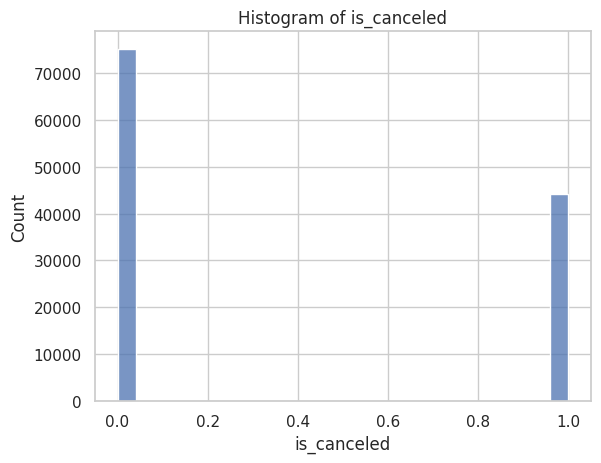

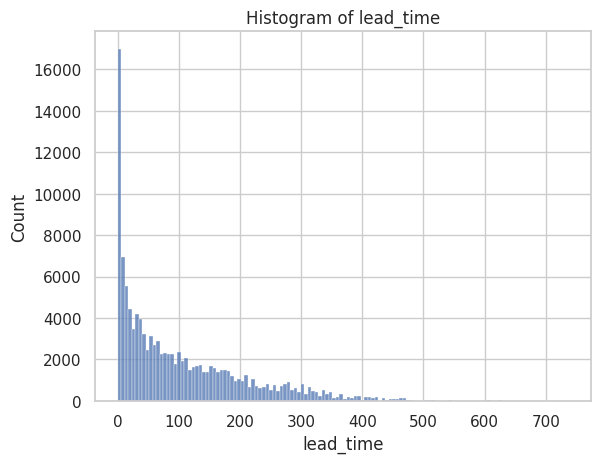

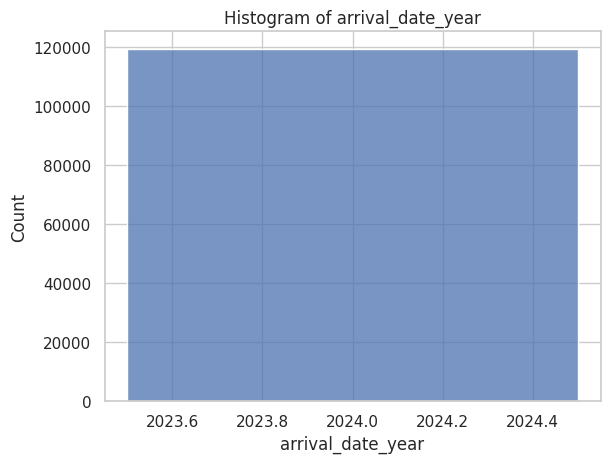

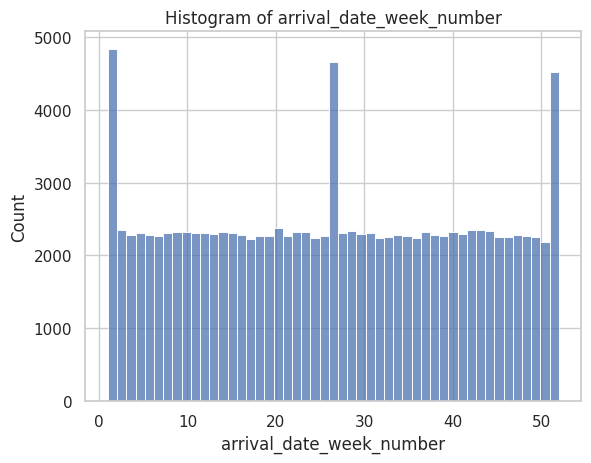

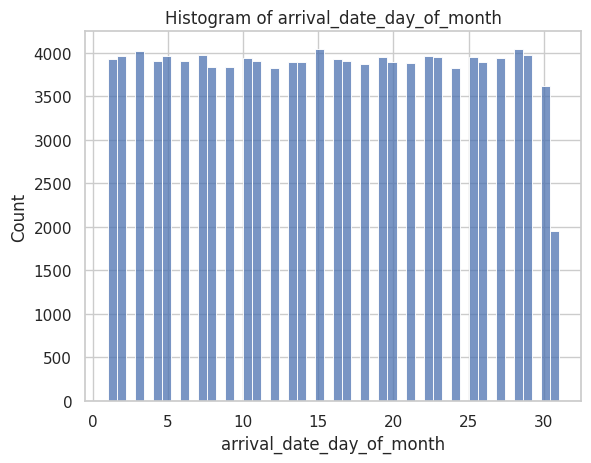

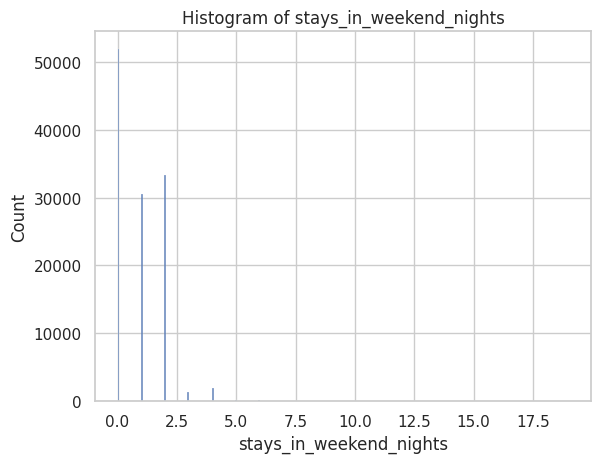

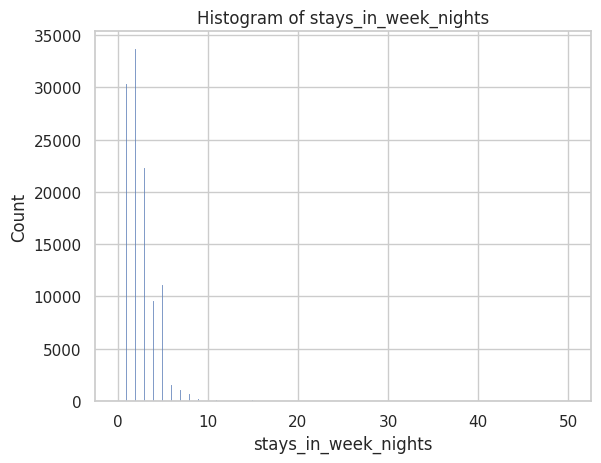

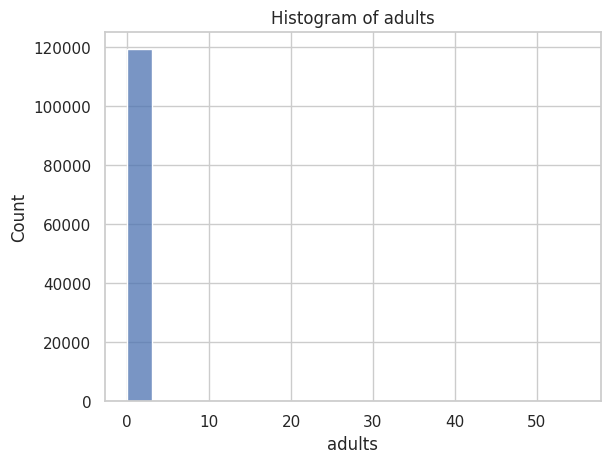

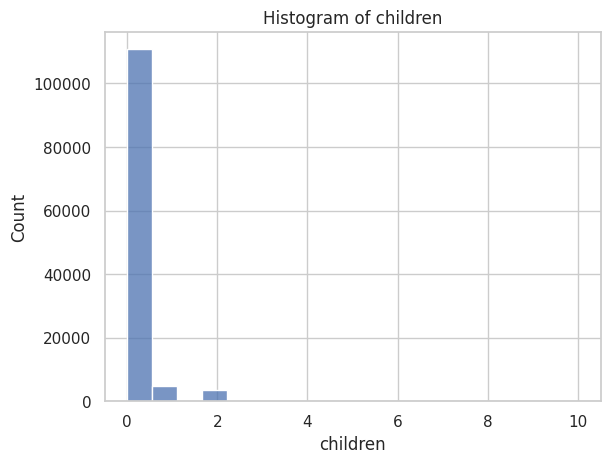

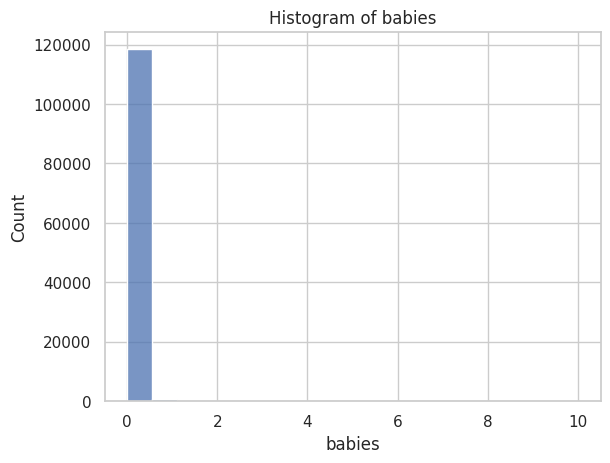

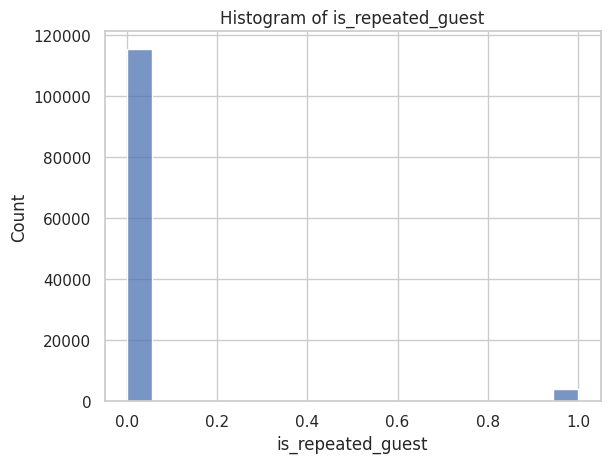

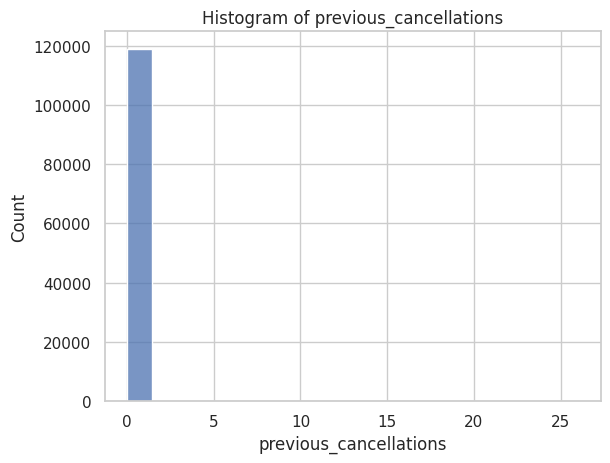

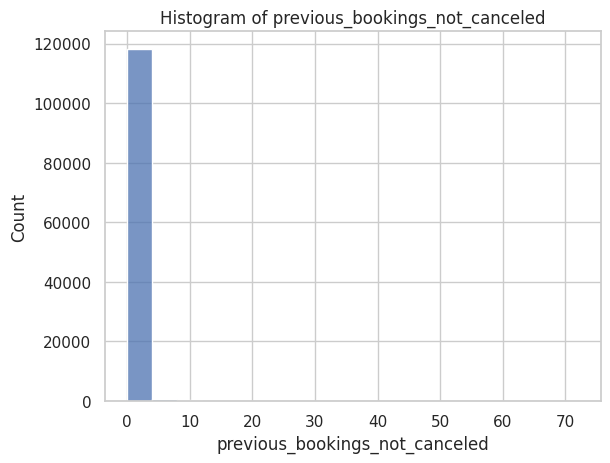

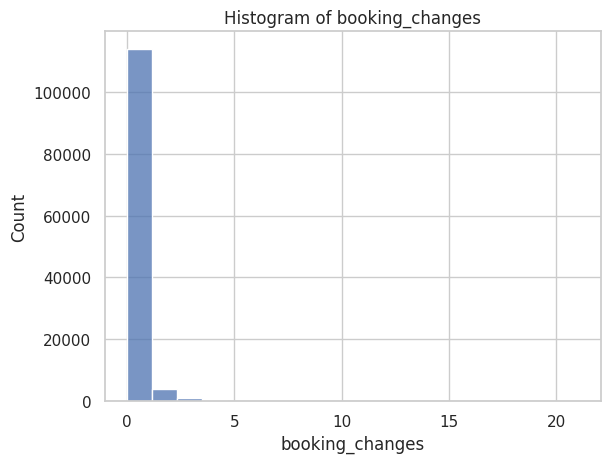

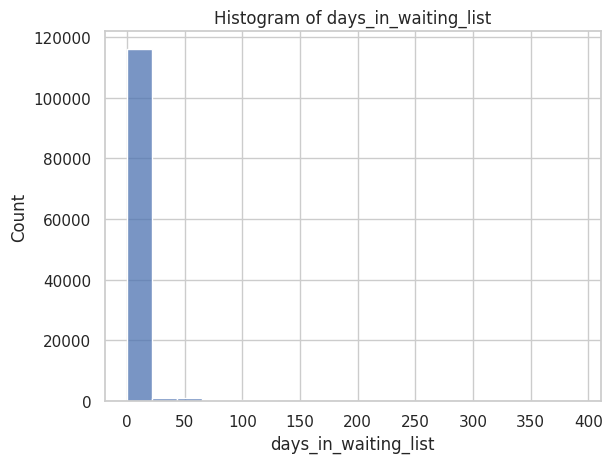

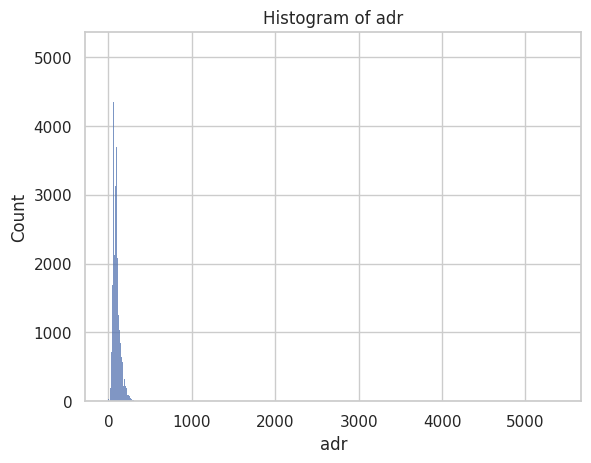

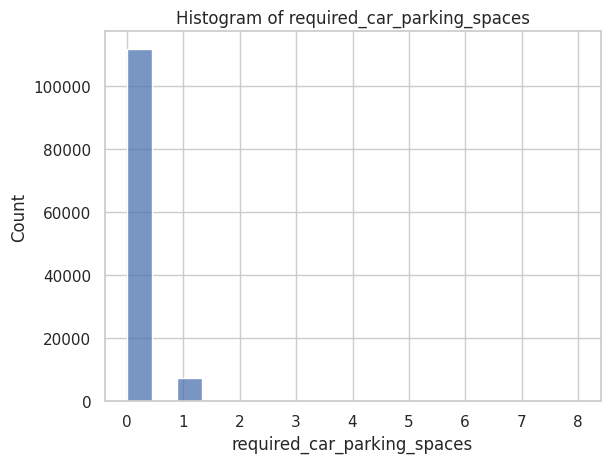

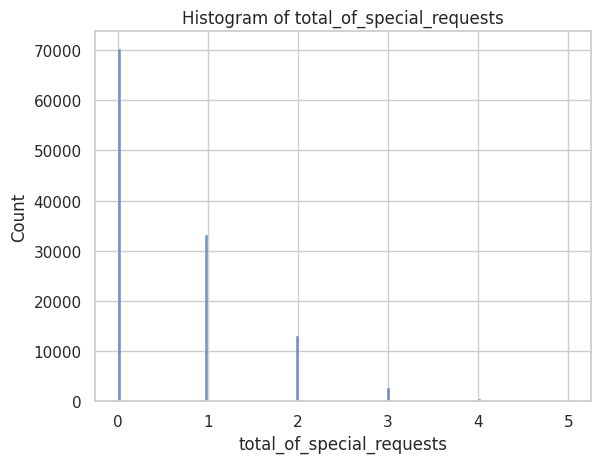

In [ ]:

# Plot histograms for numeric columns
for col in df.select_dtypes(include="number").columns:
    plt.figure()
    sns.histplot(data=df, x=col, kde=False)
    plt.title(f'Histogram of {col}')
    plt.show()


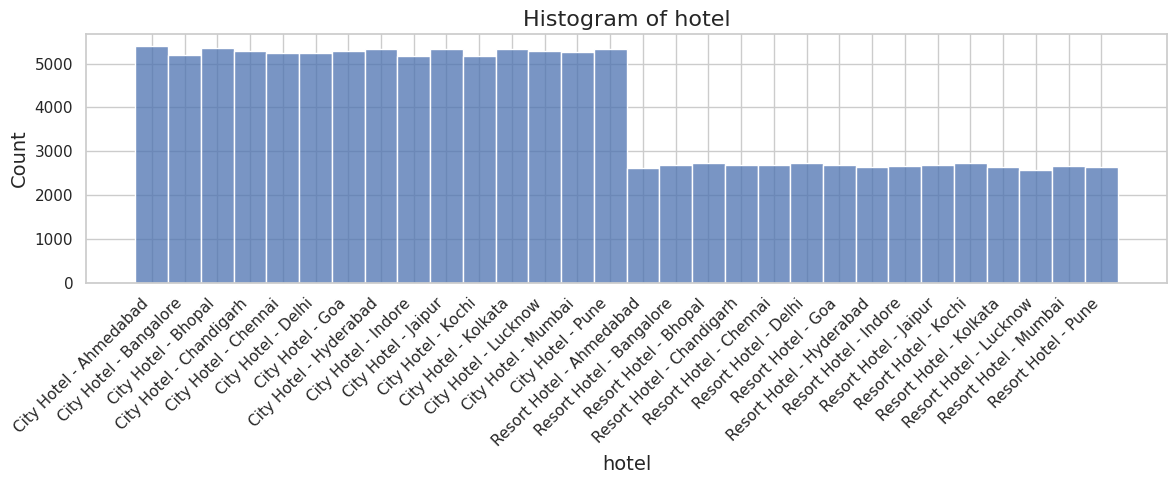

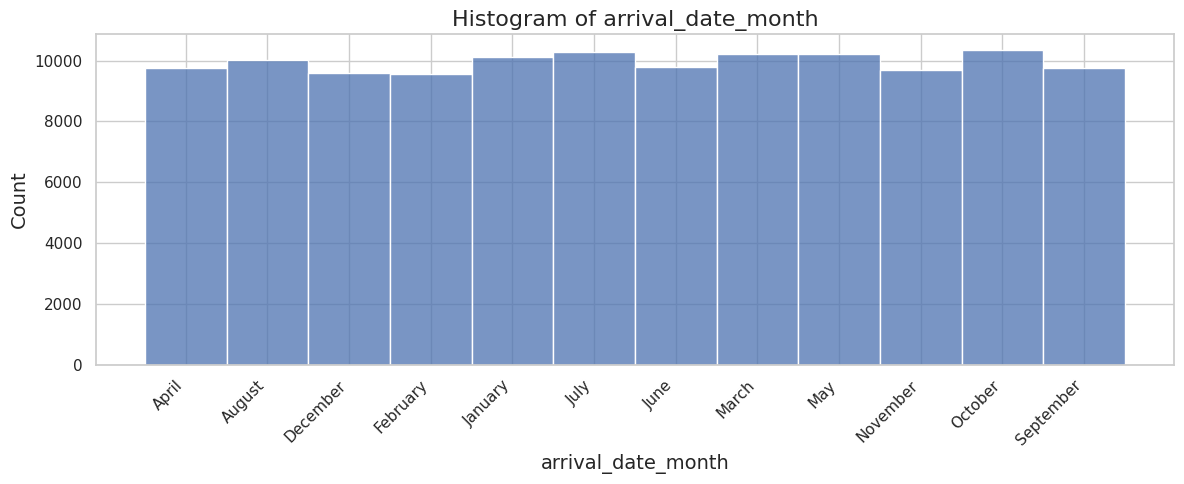

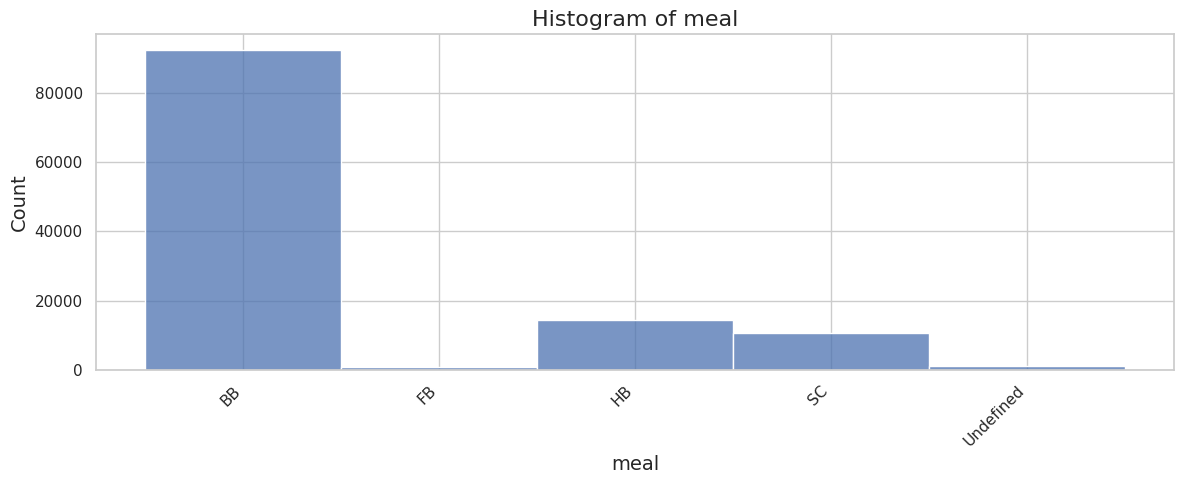

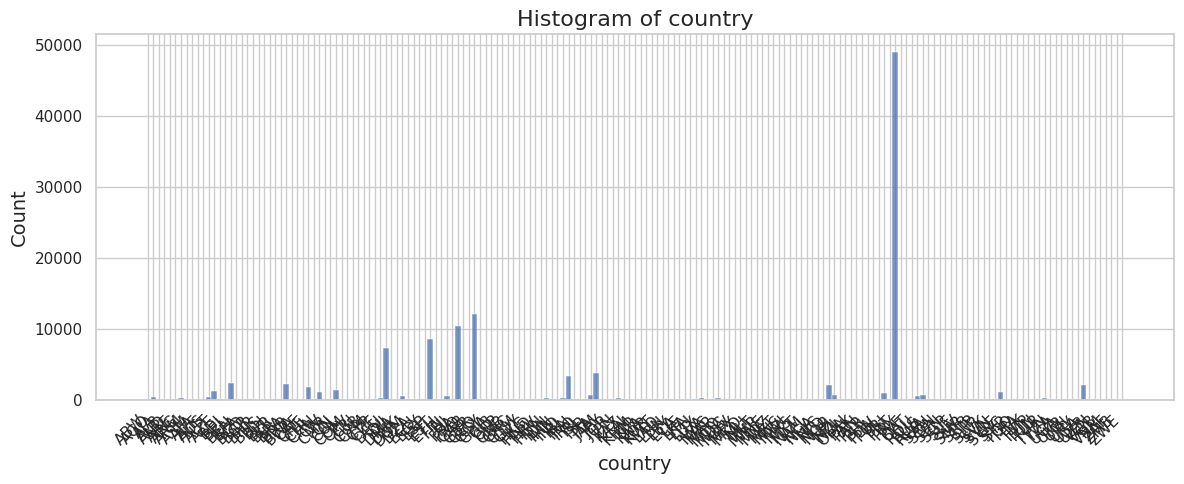

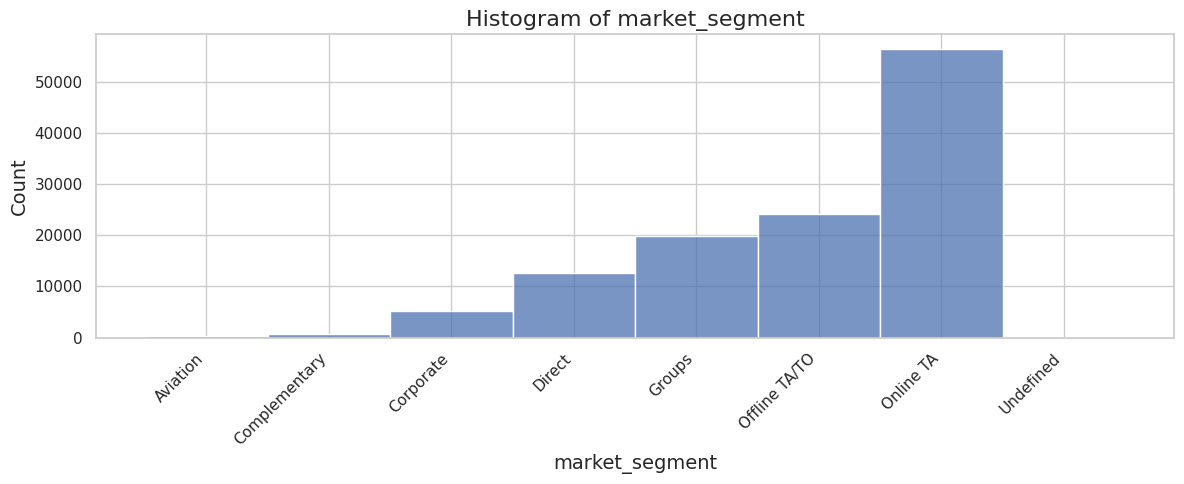

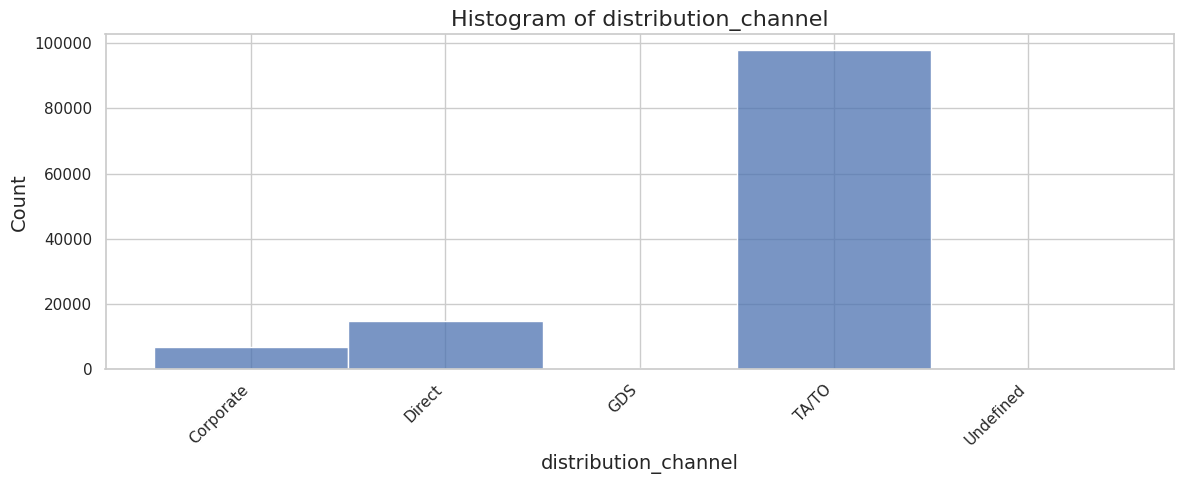

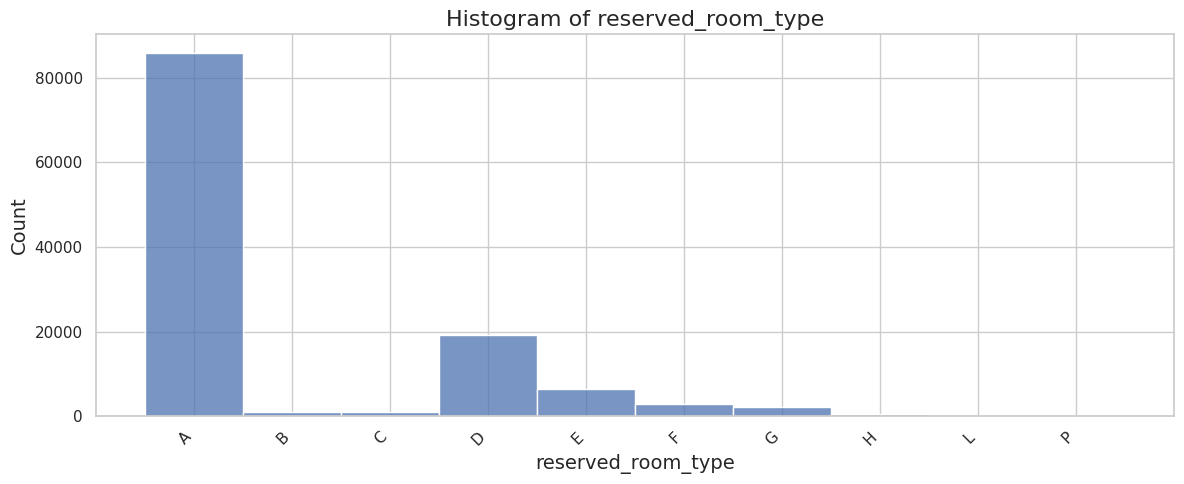

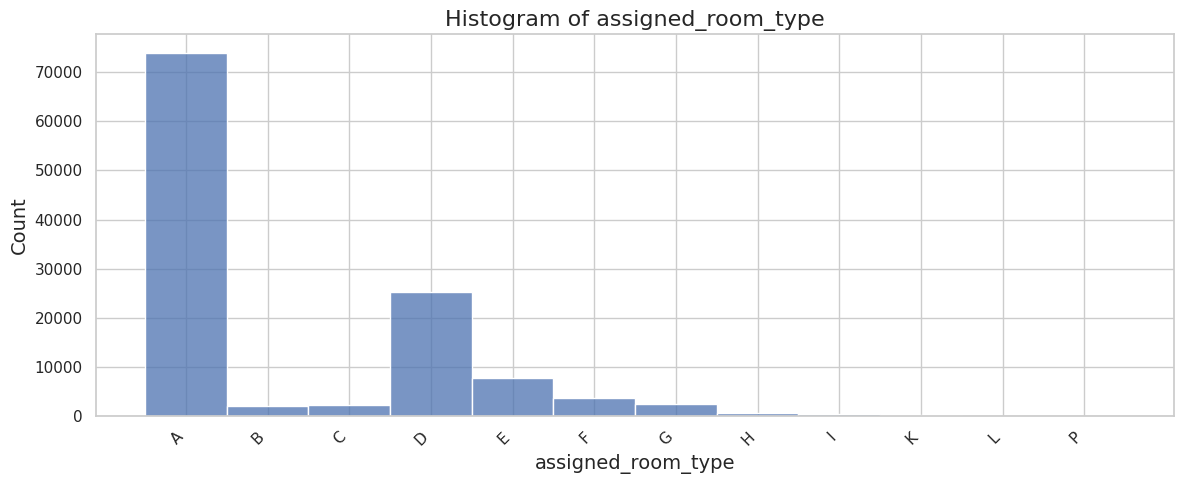

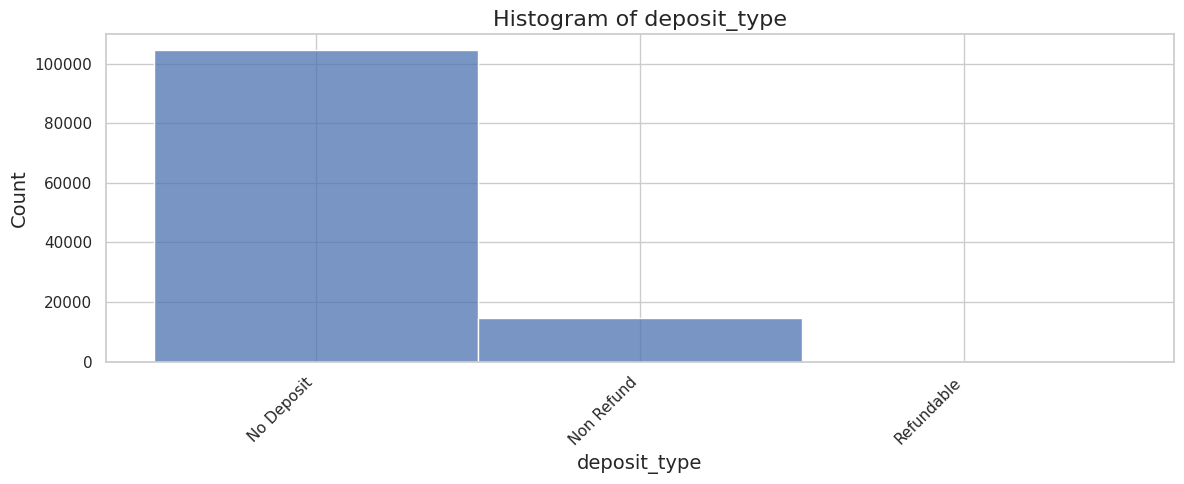

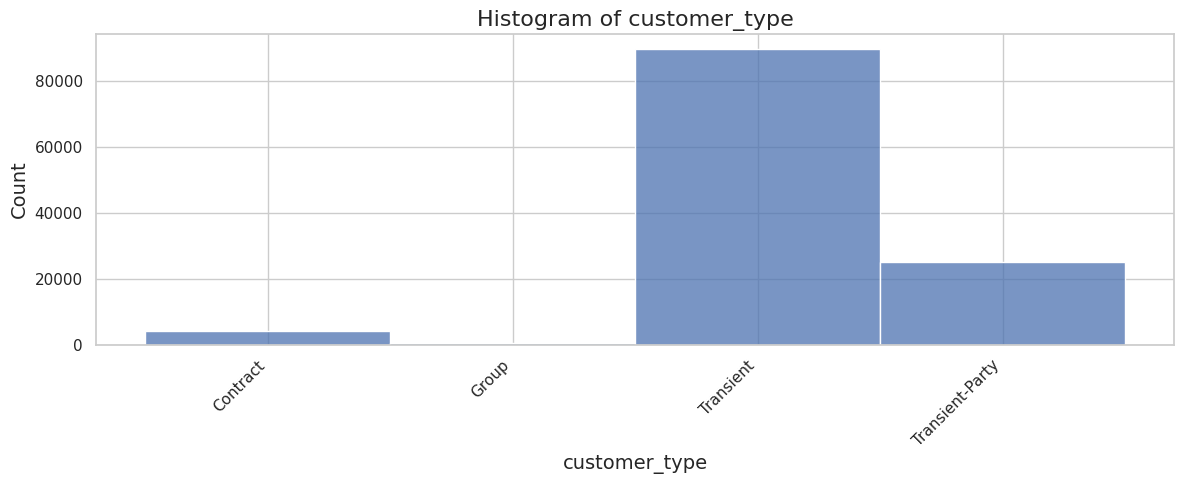

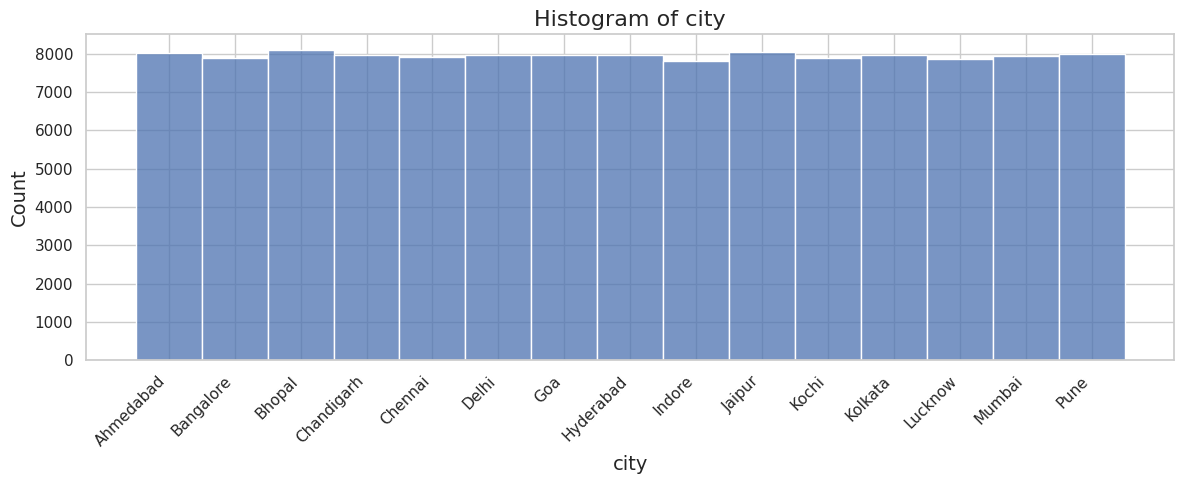

In [ ]:

# Plot histograms for numeric columns
for col in df.select_dtypes(include="category").columns:
    plt.figure(figsize=(12, 5))

    ax = sns.histplot(data=df, x=col, kde=False)

    ax.set_title(f'Histogram of {col}', fontsize=16)
    ax.set_xlabel(col, fontsize=14)
    ax.set_ylabel('Count', fontsize=14)


    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()



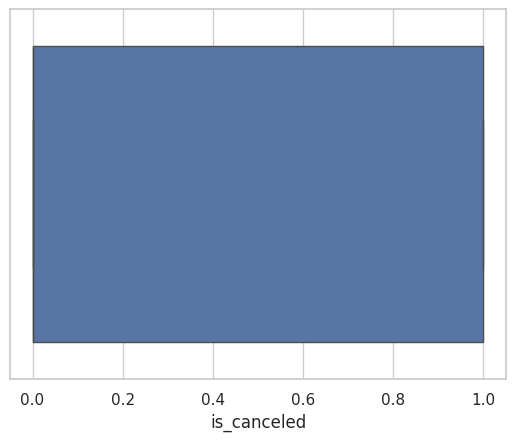

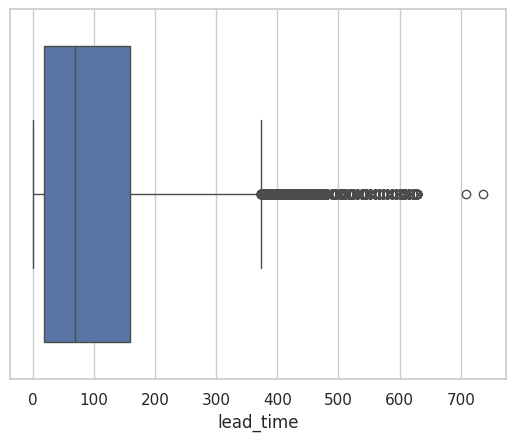

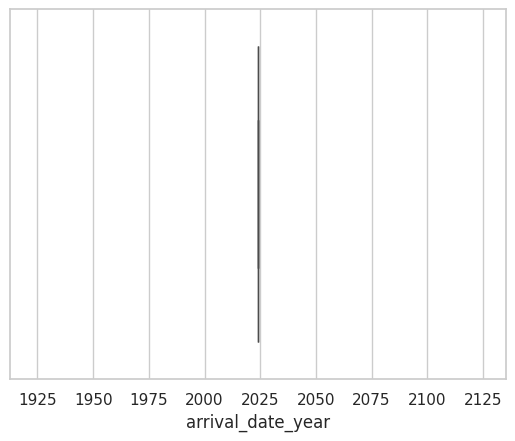

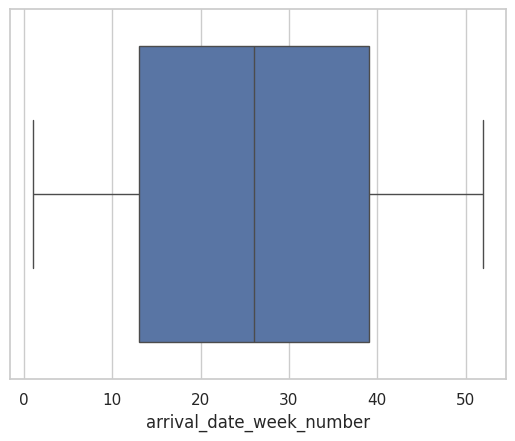

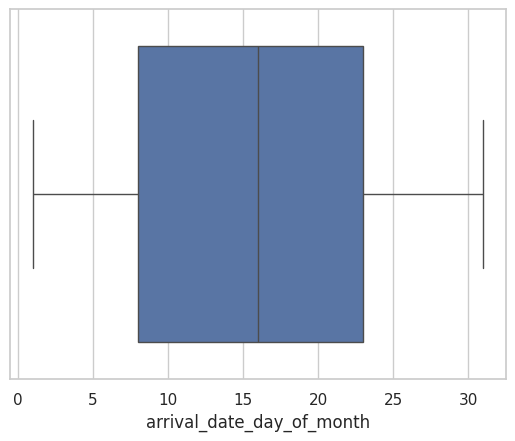

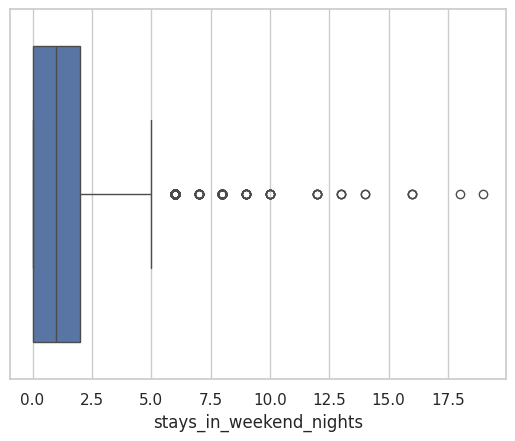

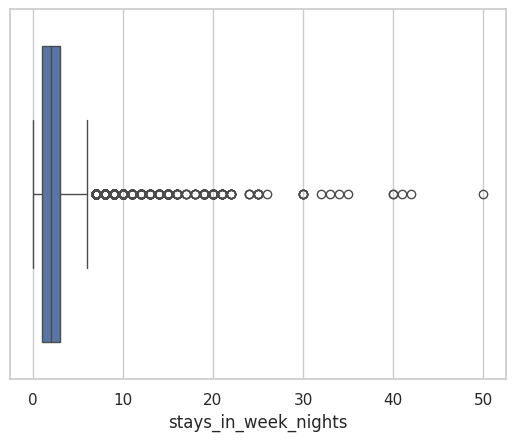

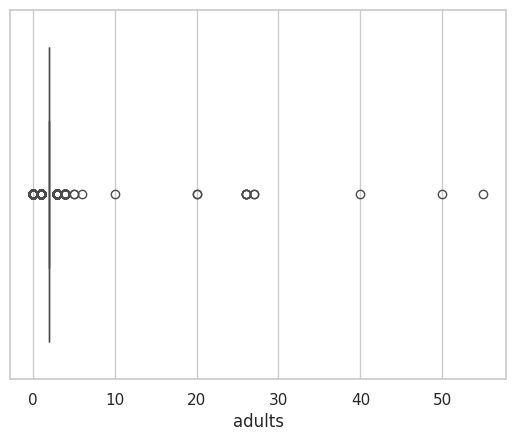

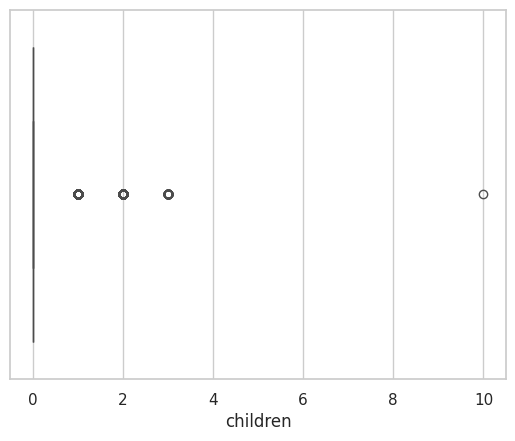

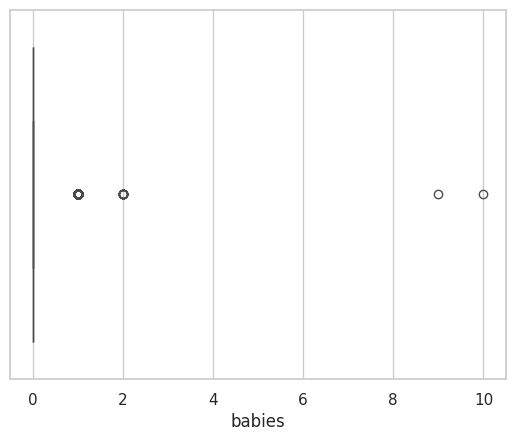

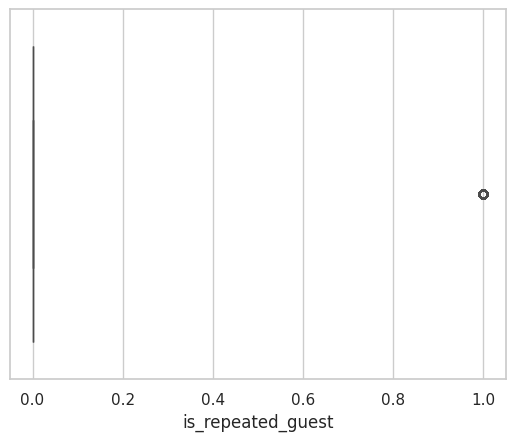

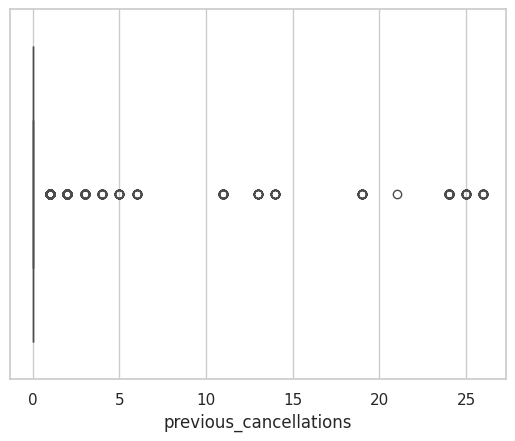

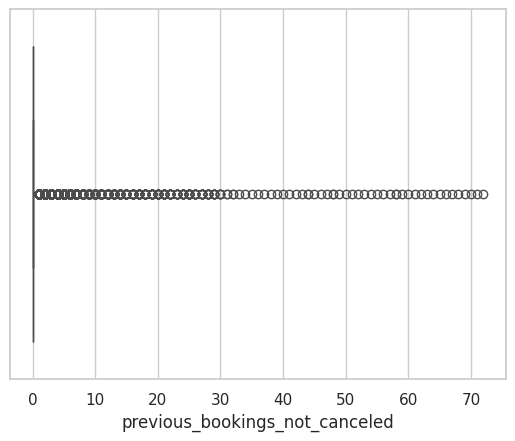

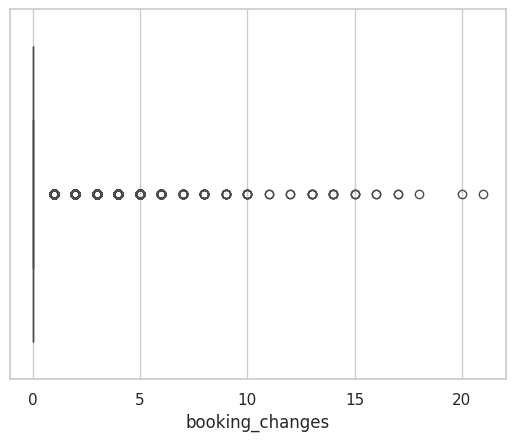

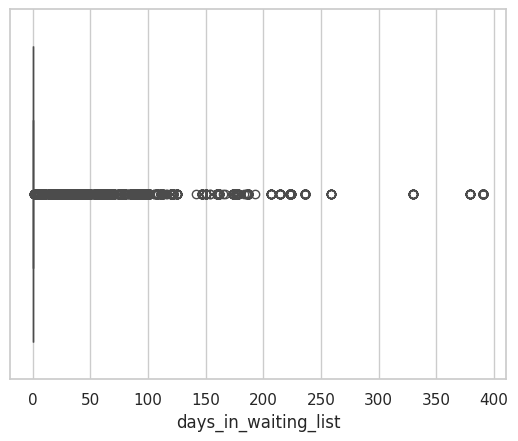

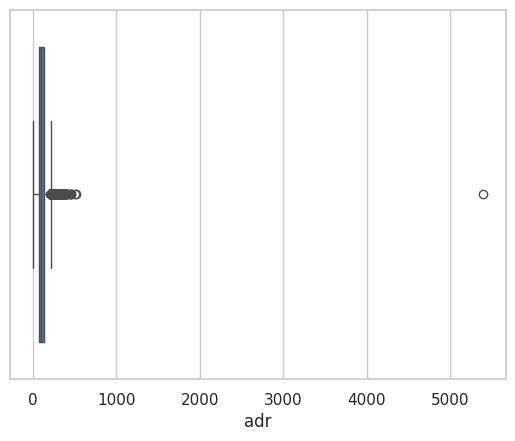

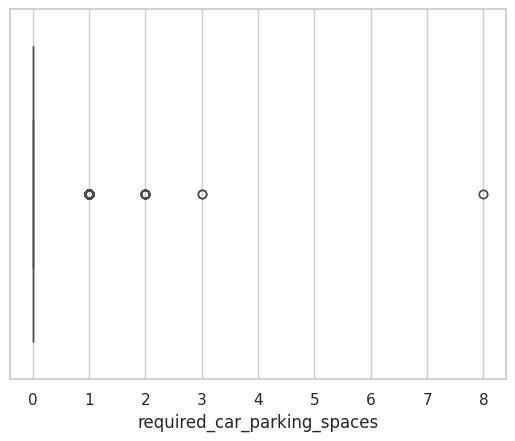

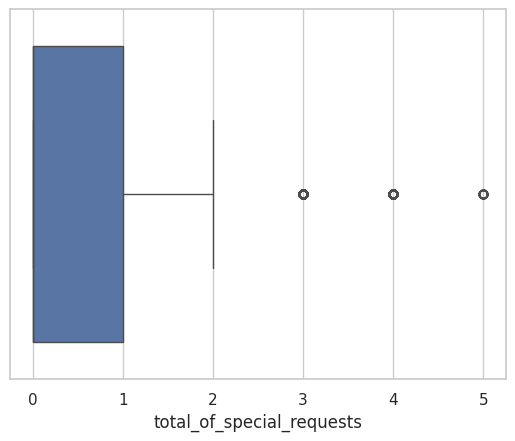

In [ ]:
# Boxplots before handling outliers
for i in df.select_dtypes(include= "number").columns:
  sns.boxplot(data=df,x=i)
  plt.show()

In [ ]:
# Define the whisker function
def whisker(col):
    q1, q3 = np.percentile(col, [25, 75])
    iqr = q3 - q1
    lw = q1 - 1.5 * iqr
    uw = q3 + 1.5 * iqr
    return lw, uw

In [ ]:
# Numerical columns selected for outlier handling
outlier_cols = ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month',
                   'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
                   'children', 'babies', 'booking_changes', 'days_in_waiting_list',
                   'adr', 'required_car_parking_spaces', 'total_of_special_requests',
                   'got_reserved_room']
outlier_cols = [c for c in outlier_cols if c in df.columns]

# Capping outliers using IQR
for col in outlier_cols:
    lw, uw = whisker(df[col])
    df[col] = np.where(df[col] < lw, lw, df[col])
    df[col] = np.where(df[col] > uw, uw, df[col])

# Extra domain rule for children (only if it exists)
if 'children' in df.columns:
    df['children'] = np.where(df['children'] > 3, 3, df['children'])


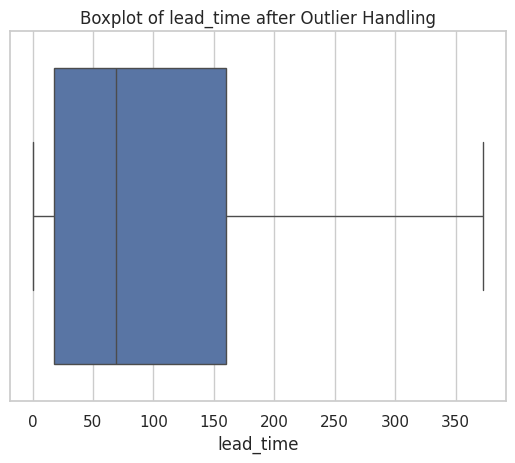

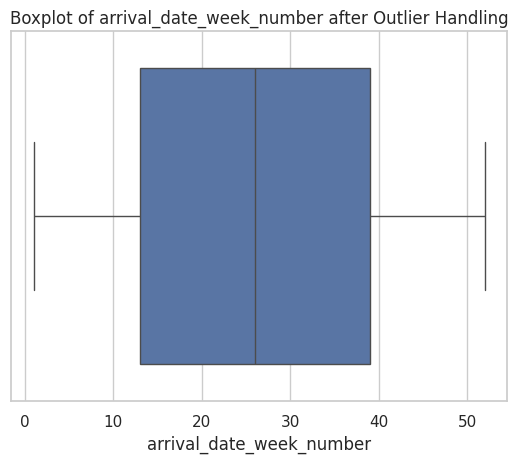

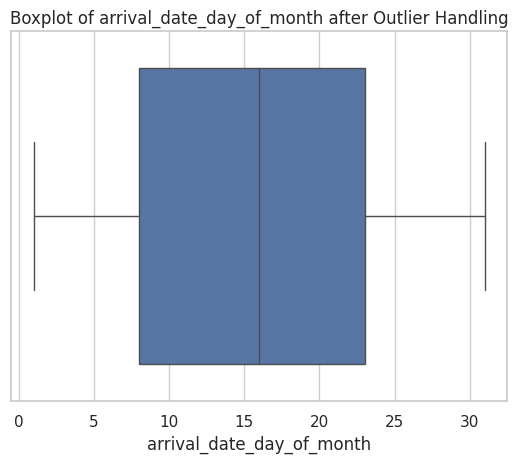

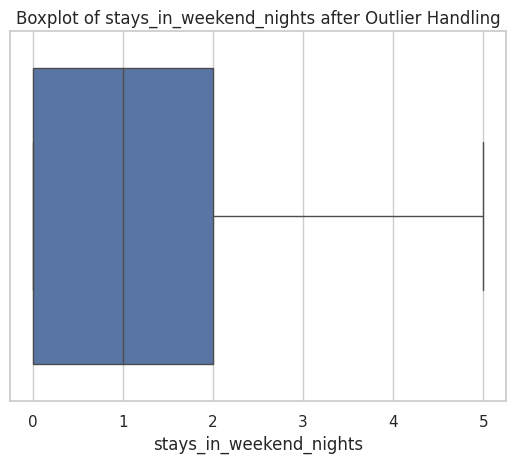

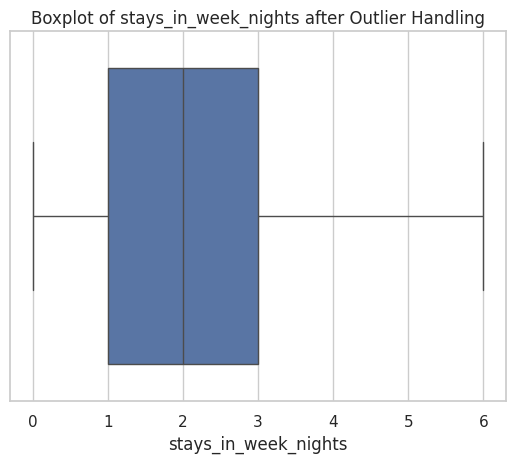

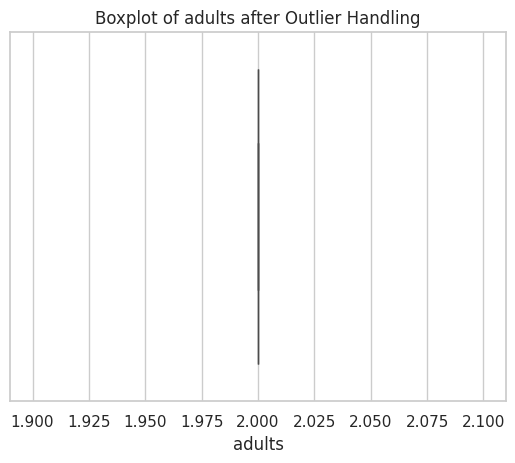

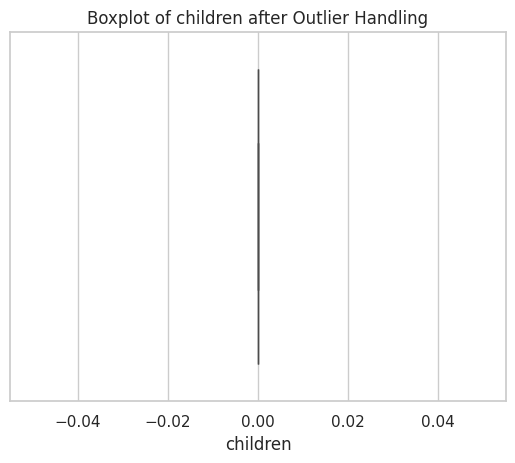

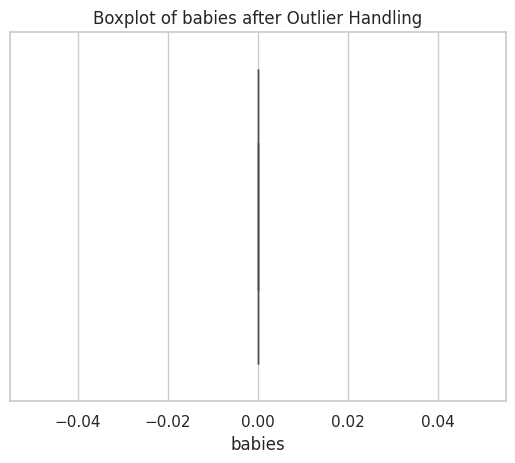

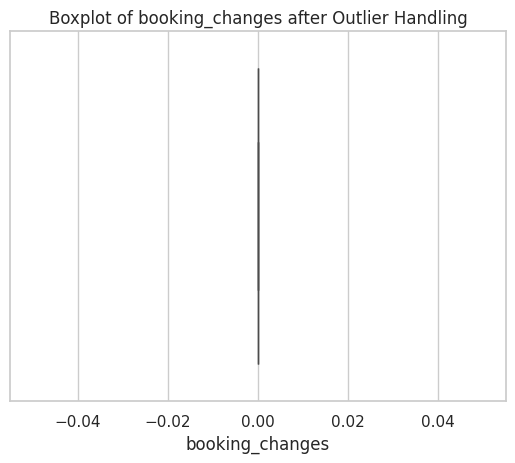

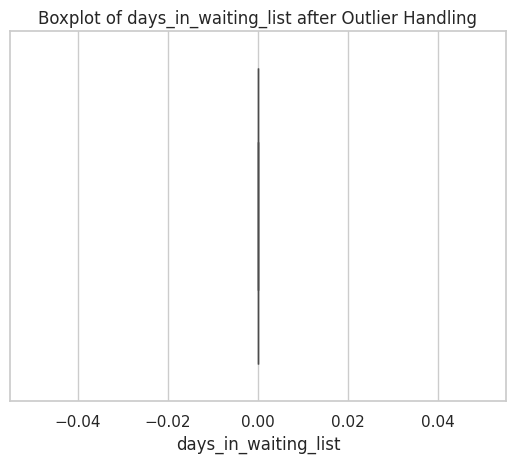

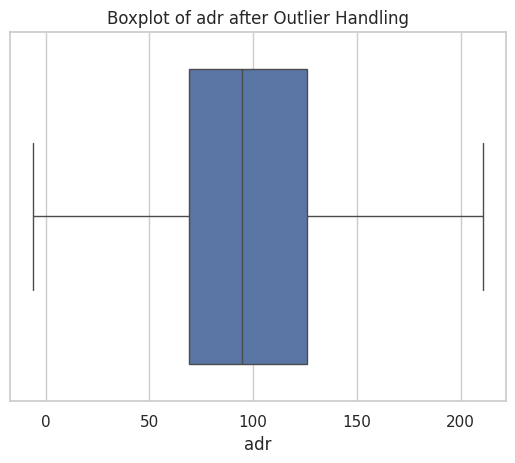

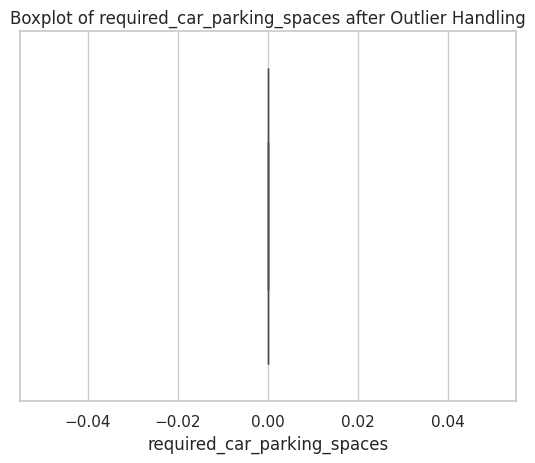

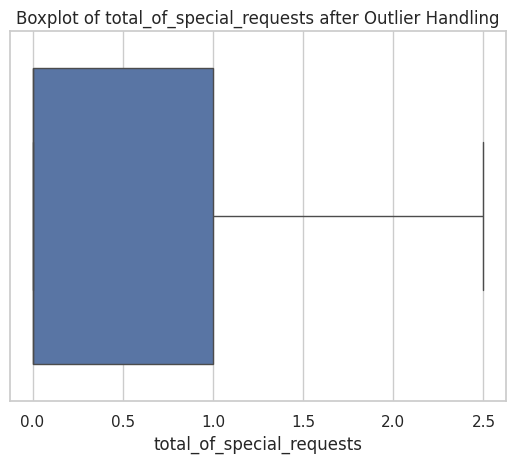

In [ ]:
# Boxplots after handling outliers
for col in outlier_cols:
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col} after Outlier Handling')
    plt.show()


In [ ]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns  # pick categorical cols
unique_counts = df[cat_cols].nunique(dropna=False).sort_values(ascending=False)

unique_counts


,0
country,177
hotel,30
city,15
assigned_room_type,12
arrival_date_month,12
reserved_room_type,10
market_segment,8
meal,5
distribution_channel,5
customer_type,4


In [ ]:
month_map = {
    'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
}

df['arrival_month_num'] = df['arrival_date_month'].map(month_map)


In [ ]:
# frequency
hotel_freq = df['hotel'].value_counts(normalize=True)
df['hotel_freq'] = df['hotel'].map(hotel_freq)


country_freq = df['country'].value_counts(normalize=True)
df['country_freq'] = df['country'].map(country_freq)


In [ ]:

label_cols = ['meal','market_segment','deposit_type','customer_type','distribution_channel']

encoders = {}

for col in label_cols:
    le = LabelEncoder()
    # convert to string to avoid NaN issues
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

In [ ]:

onehot_cols = ['city']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_ohe = ohe.fit_transform(df[onehot_cols].astype(str))

ohe_names = ohe.get_feature_names_out(onehot_cols)
df_city_ohe = pd.DataFrame(X_ohe, columns=ohe_names, index=df.index)

# add new cols + drop old city col
df = pd.concat([df.drop(columns=onehot_cols), df_city_ohe], axis=1)

In [ ]:
# After creating arrival_month_num, hotel_freq, country_freq
df = df.drop(columns=['arrival_date_month', 'hotel', 'country'], errors='ignore')


In [ ]:
df.shape

(119327, 43)

In [ ]:
# Count missing values
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_counts / len(df) * 100).round(2)
missing_table = pd.concat([missing_counts, missing_percent], axis=1)
missing_table.columns = ['missing_count', 'missing_percent']
print(missing_table.head(33))
cat_cols = df.select_dtypes(include=['object', 'category']).columns  # pick categorical cols
unique_counts = df[cat_cols].nunique(dropna=False).sort_values(ascending=False)

unique_counts


                                missing_count  missing_percent
is_canceled                                 0              0.0
lead_time                                   0              0.0
arrival_date_year                           0              0.0
arrival_date_week_number                    0              0.0
arrival_date_day_of_month                   0              0.0
stays_in_weekend_nights                     0              0.0
stays_in_week_nights                        0              0.0
adults                                      0              0.0
children                                    0              0.0
babies                                      0              0.0
meal                                        0              0.0
market_segment                              0              0.0
distribution_channel                        0              0.0
is_repeated_guest                           0              0.0
previous_cancellations                      0          

,0
assigned_room_type,12
arrival_month_num,12
reserved_room_type,10


In [ ]:
#-----------------------------

In [ ]:

df_eda = pd.read_csv('/content/drive/MyDrive/hotel_bookings.csv')

#  cleaning for EDA
df_eda = df_eda.drop(columns=['company'], errors='ignore')

# Fill missing
if 'country' in df_eda.columns:
    df_eda['country'] = df_eda['country'].fillna(df_eda['country'].mode(dropna=True)[0])

if 'children' in df_eda.columns:
    df_eda['children'] = df_eda['children'].fillna(0).astype(int)

# Avoid leakage fields in EDA
df_eda = df_eda.drop(columns=['reservation_status'], errors='ignore')

df_eda.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,city
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,3,No Deposit,NaN,0,Transient,0.0,0,0,12:16 AM,Chandigarh
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,4,No Deposit,NaN,0,Transient,0.0,0,0,12:56 AM,Mumbai
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,0,No Deposit,NaN,0,Transient,75.0,0,0,12:46 AM,Delhi
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,12:07 AM,Kolkata
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,12:27 AM,Lucknow


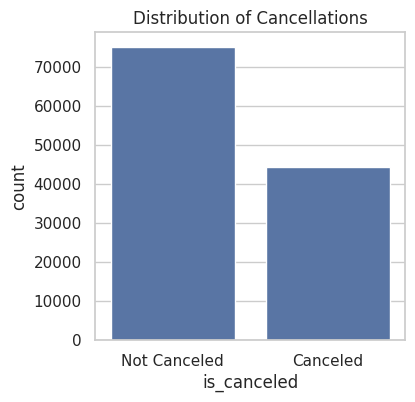

In [ ]:
plt.figure(figsize=(4,4))
sns.countplot(data=df_eda, x='is_canceled')
plt.xticks([0,1], ['Not Canceled', 'Canceled'])
plt.title('Distribution of Cancellations')
plt.show()



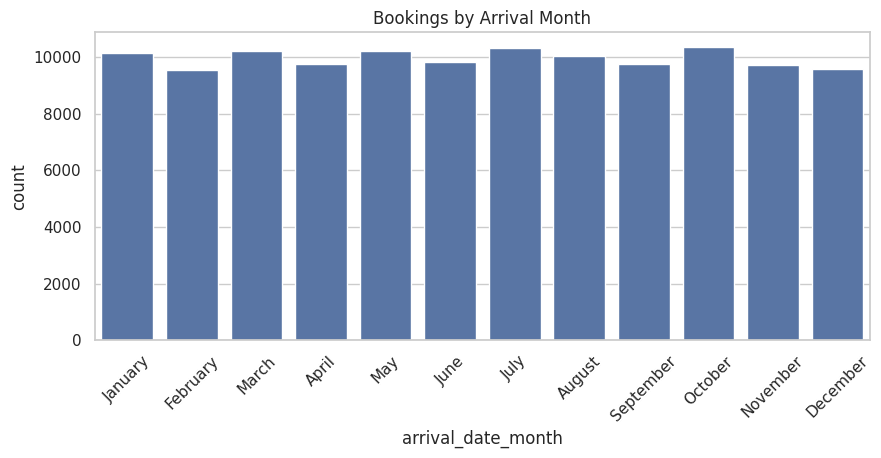

In [ ]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

plt.figure(figsize=(10,4))
sns.countplot(data=df_eda, x='arrival_date_month', order=month_order)
plt.xticks(rotation=45)
plt.title('Bookings by Arrival Month')
plt.show()


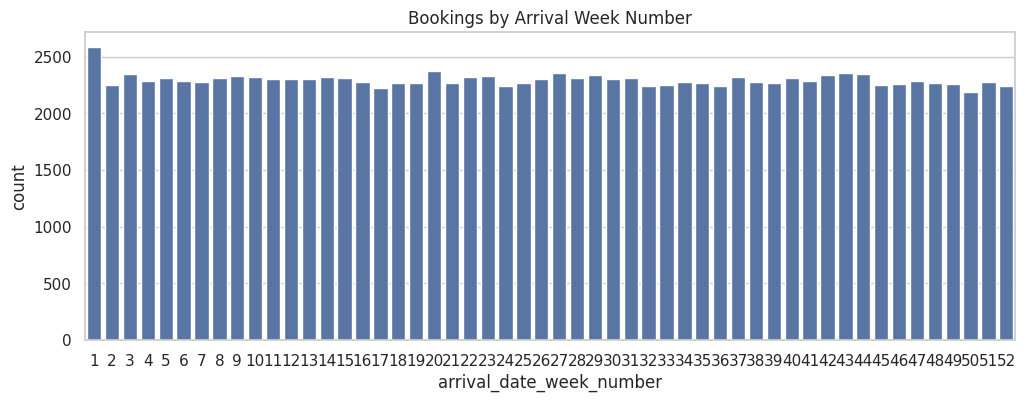

In [ ]:
plt.figure(figsize=(12,4))
sns.countplot(data=df_eda, x='arrival_date_week_number')
plt.title('Bookings by Arrival Week Number')
plt.show()


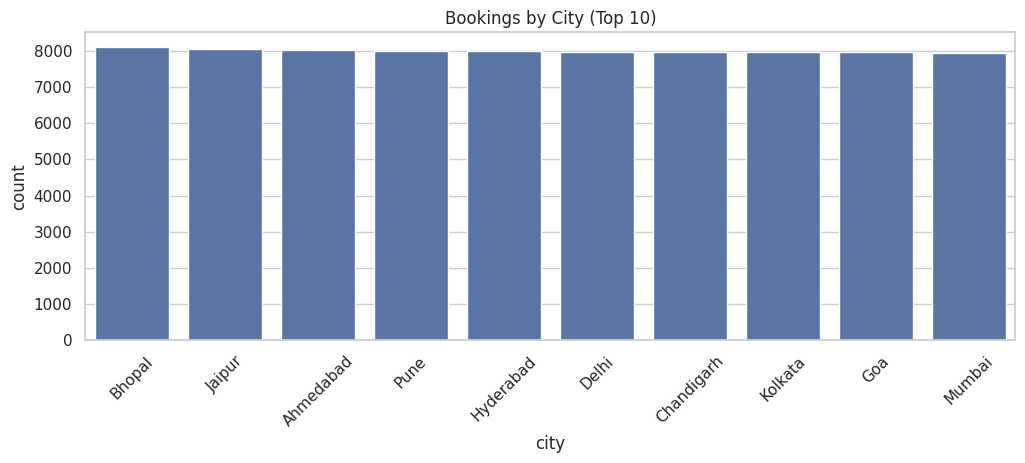

In [ ]:
top_cities = df_eda['city'].value_counts().head(10).index

plt.figure(figsize=(12,4))
sns.countplot(data=df_eda[df_eda['city'].isin(top_cities)], x='city', order=top_cities)  # [web:189]
plt.xticks(rotation=45)
plt.title('Bookings by City (Top 10)')
plt.show()


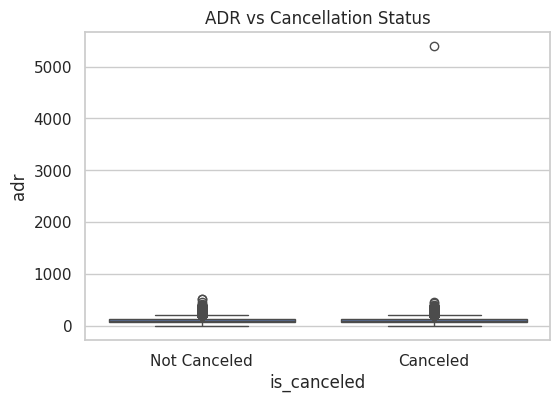

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_eda, x='is_canceled', y='adr')
plt.xticks([0,1], ['Not Canceled', 'Canceled'])
plt.title('ADR vs Cancellation Status')
plt.show()


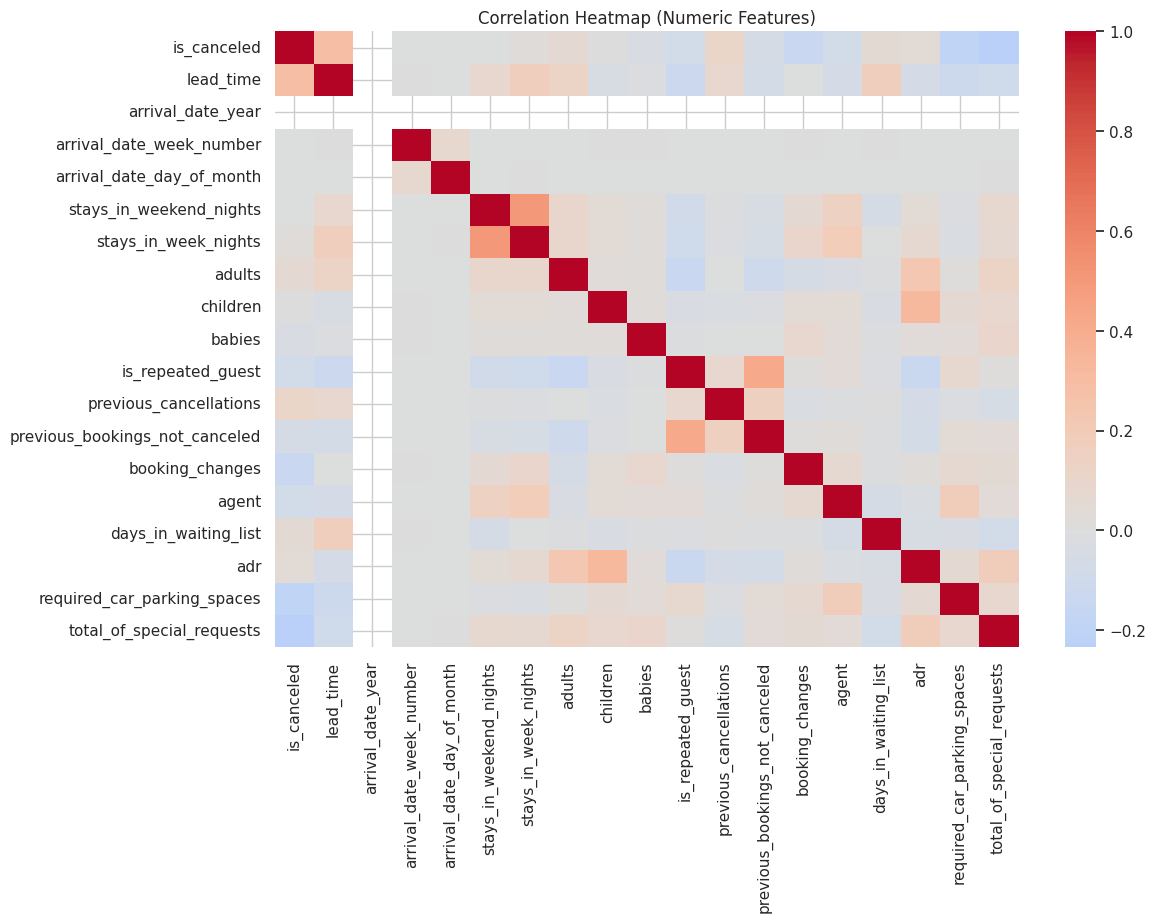

In [ ]:
corr = df_eda.select_dtypes(include='number').corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()


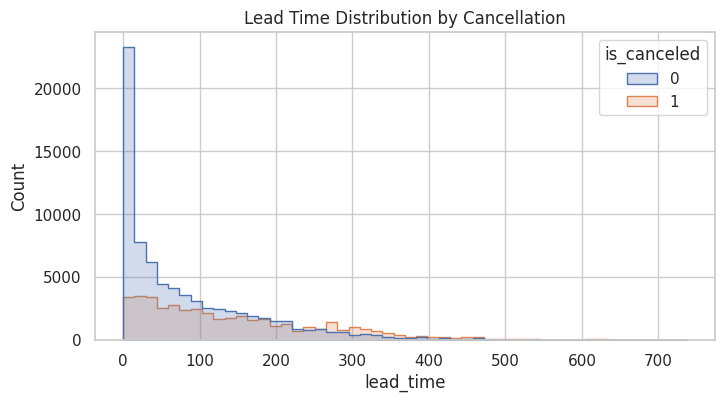

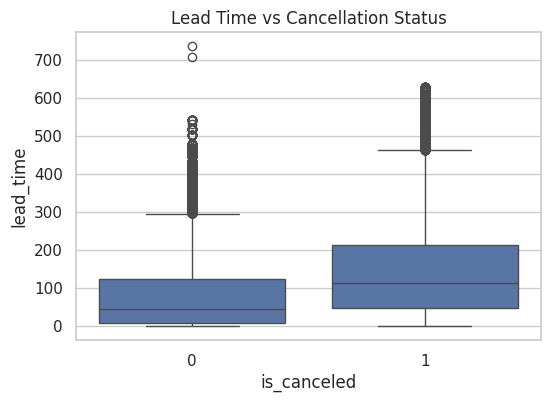

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(data=df_eda, x='lead_time', hue='is_canceled', bins=50, element='step')
plt.title('Lead Time Distribution by Cancellation')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df_eda, x='is_canceled', y='lead_time')
plt.title('Lead Time vs Cancellation Status')
plt.show()


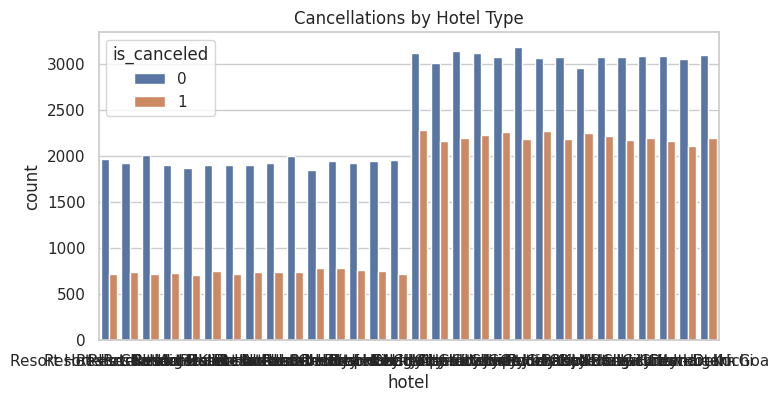

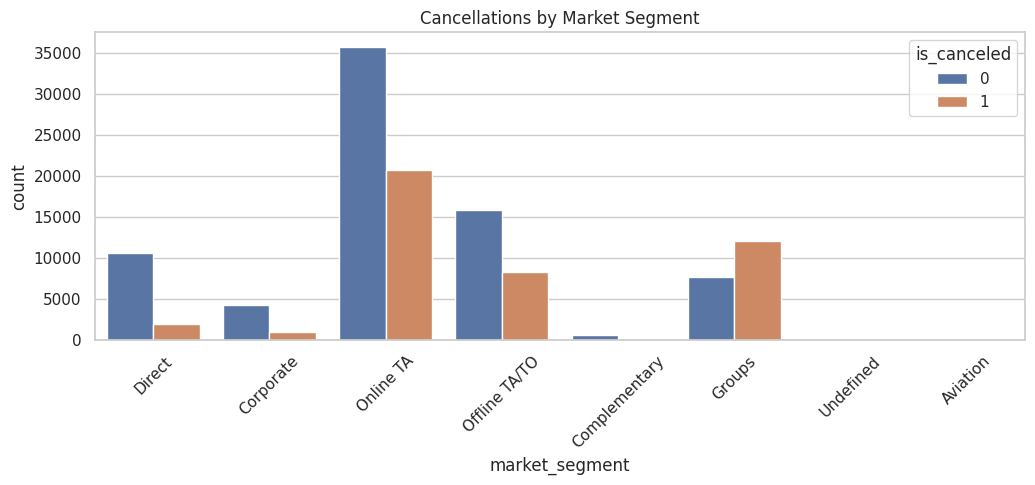

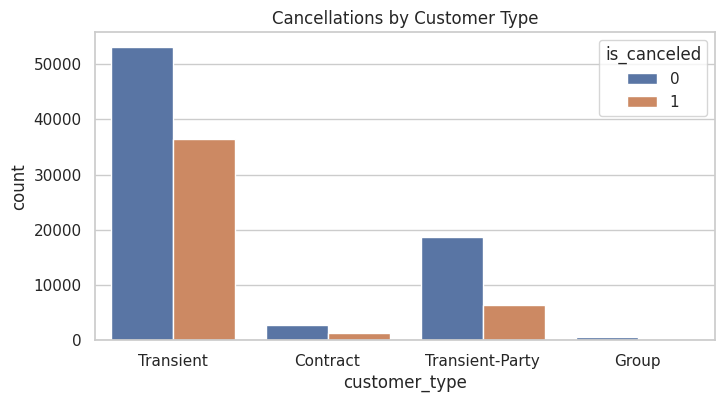

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(data=df_eda, x='hotel', hue='is_canceled')
plt.title('Cancellations by Hotel Type')
plt.show()

plt.figure(figsize=(12,4))
sns.countplot(data=df_eda, x='market_segment', hue='is_canceled')
plt.xticks(rotation=45)
plt.title('Cancellations by Market Segment')
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(data=df_eda, x='customer_type', hue='is_canceled')
plt.title('Cancellations by Customer Type')
plt.show()


In [ ]:
#**********

In [ ]:
#******************

In [ ]:
# Convert to string first
df['got_reserved_room'] = (df['reserved_room_type'].astype(str) ==
                          df['assigned_room_type'].astype(str)).astype(int)

df = df.drop(columns=['reserved_room_type', 'assigned_room_type'])


In [ ]:
df['arrival_date'] = pd.to_datetime(
    dict(year=df['arrival_date_year'], month=df['arrival_month_num'], day=df['arrival_date_day_of_month']),
    errors='coerce'
)
df['arrival_dayofweek'] = df['arrival_date'].dt.dayofweek


In [ ]:
# 3) arrival date: drop" and year because all values is 2024
if 'arrival_date' in df.columns:
    df=df.drop(columns=['arrival_date'])
if 'arrival_date_year' in df.columns:
    df=df.drop(columns=['arrival_date_year'])


In [ ]:
# Total stay
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']  # [web:444]

# Total guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']  # [web:444]

# Total previous bookings
df['total_previous_bookings'] = df['previous_cancellations'] + df['previous_bookings_not_canceled']  # [web:444]


In [ ]:
df.shape

(119327, 45)

In [ ]:
corr = df.select_dtypes(include='number').corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]
print("Highly correlated columns to drop:", to_drop)

df = df.drop(columns=to_drop)


Highly correlated columns to drop: ['total_stay']


In [ ]:
df['arrival_month_num'] = df['arrival_month_num'].astype(int)


In [ ]:
# Remove duplicates AFTER feature engineering
print(f"Shape before drop_duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape after drop_duplicates: {df.shape}")



Shape before drop_duplicates: (119288, 44)
Shape after drop_duplicates: (119288, 44)


In [ ]:
# Count missing values
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_counts / len(df) * 100).round(2)
missing_table = pd.concat([missing_counts, missing_percent], axis=1)
missing_table.columns = ['missing_count', 'missing_percent']
print(missing_table.head(44))
cat_cols = df.select_dtypes(include=['object', 'category']).columns  # pick categorical cols
unique_counts = df[cat_cols].nunique(dropna=False).sort_values(ascending=False)

unique_counts


                                missing_count  missing_percent
is_canceled                                 0              0.0
lead_time                                   0              0.0
arrival_date_week_number                    0              0.0
arrival_date_day_of_month                   0              0.0
stays_in_weekend_nights                     0              0.0
stays_in_week_nights                        0              0.0
adults                                      0              0.0
children                                    0              0.0
babies                                      0              0.0
meal                                        0              0.0
market_segment                              0              0.0
distribution_channel                        0              0.0
is_repeated_guest                           0              0.0
previous_cancellations                      0              0.0
previous_bookings_not_canceled              0          

,0


In [ ]:
#--------------------

Class counts: Counter({0: 75149, 1: 44139})


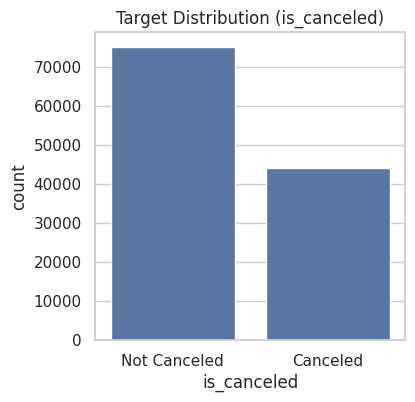

In [ ]:

y = df['is_canceled']

print("Class counts:", Counter(y))

plt.figure(figsize=(4,4))
sns.countplot(x=y)
plt.xticks([0,1], ['Not Canceled', 'Canceled'])
plt.title('Target Distribution (is_canceled)')
plt.show()

In [ ]:
# 60/20/20 SPLIT (60% train, 20% val, 20% test)
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", Counter(y_train))
print("Val:  ", Counter(y_val))
print("Test: ", Counter(y_test))


Train: Counter({0: 45089, 1: 26483})
Val:   Counter({0: 15030, 1: 8828})
Test:  Counter({0: 15030, 1: 8828})


Before SMOTE: Counter({0: 45089, 1: 26483})
After SMOTE : Counter({0: 45089, 1: 45089})


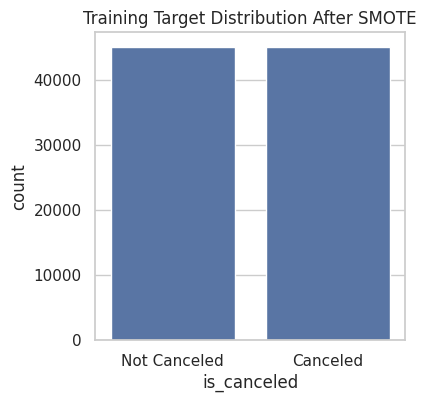

In [ ]:
# SMOTE (TRAIN ONLY - AFTER SPLIT)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE :", Counter(y_train_sm))

plt.figure(figsize=(4,4))
sns.countplot(x=y_train_sm)
plt.xticks([0,1], ['Not Canceled', 'Canceled'])
plt.title('Training Target Distribution After SMOTE')
plt.show()

# ✅ REPLACE for all models
X_train = X_train_sm
y_train = y_train_sm


In [ ]:
# Count missing values
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_counts / len(df) * 100).round(2)
missing_table = pd.concat([missing_counts, missing_percent], axis=1)
missing_table.columns = ['missing_count', 'missing_percent']
print(missing_table.head(44))
cat_cols = df.select_dtypes(include=['object', 'category']).columns
unique_counts = df[cat_cols].nunique(dropna=False).sort_values(ascending=False)


unique_counts

                                missing_count  missing_percent
is_canceled                                 0              0.0
lead_time                                   0              0.0
arrival_date_week_number                    0              0.0
arrival_date_day_of_month                   0              0.0
stays_in_weekend_nights                     0              0.0
stays_in_week_nights                        0              0.0
adults                                      0              0.0
children                                    0              0.0
babies                                      0              0.0
meal                                        0              0.0
market_segment                              0              0.0
distribution_channel                        0              0.0
is_repeated_guest                           0              0.0
previous_cancellations                      0              0.0
previous_bookings_not_canceled              0          

,0


In [ ]:
# 1. COLUMNS WITH NaN (NAMES ONLY)
nan_columns = X.columns[X.isna().any()].tolist()
print("Columns with NaN:", nan_columns)


Columns with NaN: []


In [ ]:
#------------

In [ ]:
!pip -q install sklearn-genetic-opt


In [ ]:
# KNN + GA FEATURE SELECTION
knn = KNeighborsClassifier(n_neighbors=7)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

ga_knn = GAFeatureSelectionCV(
    estimator=knn,
    cv=cv,
    scoring="f1",
    population_size=10,
    generations=5,
    n_jobs=-1,
    verbose=True,

)

ga_knn.fit(X_train, y_train)

selected_features_knn = X_train.columns[ga_knn.support_].tolist()
print(f"KNN selected {len(selected_features_knn)} features:")
print("Selected features for KNN:", selected_features_knn)


gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	10    	0.691095	0.0202738  	0.72399    	0.651367   
1  	20    	0.728302	0.0439675  	0.777662   	0.649898   
2  	20    	0.720611	0.0299965  	0.777662   	0.687091   
3  	20    	0.721482	0.0318543  	0.777662   	0.673437   
4  	20    	0.715655	0.0111645  	0.727752   	0.687091   
5  	20    	0.724043	0.00479208 	0.734615   	0.715814   
KNN selected 23 features:
Selected features for KNN: ['adults', 'babies', 'meal', 'market_segment', 'is_repeated_guest', 'previous_cancellations', 'deposit_type', 'required_car_parking_spaces', 'total_of_special_requests', 'country_freq', 'city_Ahmedabad', 'city_Chandigarh', 'city_Chennai', 'city_Goa', 'city_Hyderabad', 'city_Jaipur', 'city_Kochi', 'city_Kolkata', 'city_Mumbai', 'city_Pune', 'got_reserved_room', 'total_guests', 'total_previous_bookings']


In [ ]:
missing = set(selected_features_knn) - set(X_train.columns)
print("Missing in X_train:", missing)

missing_val = set(selected_features_knn) - set(X_val.columns)
missing_test = set(selected_features_knn) - set(X_test.columns)
print("Missing in X_val:", missing_val)
print("Missing in X_test:", missing_test)


Missing in X_train: set()
Missing in X_val: set()
Missing in X_test: set()


In [ ]:

best_k_knn, best_f1_knn = None, -1

for k in [3, 5, 7, 9, 11]:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train[selected_features_knn], y_train)
    pred_val_tmp = knn_tmp.predict(X_val[selected_features_knn])

    f1_tmp = f1_score(y_val, pred_val_tmp)
    if f1_tmp > best_f1_knn:
        best_f1_knn, best_k_knn = f1_tmp, k

# Train best KNN again
best_model_knn = KNeighborsClassifier(n_neighbors=best_k_knn)
best_model_knn.fit(X_train[selected_features_knn], y_train)

pred_train_knn = best_model_knn.predict(X_train[selected_features_knn])
pred_val_knn   = best_model_knn.predict(X_val[selected_features_knn])
pred_test_knn  = best_model_knn.predict(X_test[selected_features_knn])

# Metrics
train_acc_knn = accuracy_score(y_train, pred_train_knn)

val_acc_knn   = accuracy_score(y_val, pred_val_knn)
val_prec_knn  = precision_score(y_val, pred_val_knn)
val_rec_knn   = recall_score(y_val, pred_val_knn)
val_f1_knn    = f1_score(y_val, pred_val_knn)
val_cm_knn    = confusion_matrix(y_val, pred_val_knn)

test_acc_knn  = accuracy_score(y_test, pred_test_knn)
test_prec_knn = precision_score(y_test, pred_test_knn)
test_rec_knn  = recall_score(y_test, pred_test_knn)
test_f1_knn   = f1_score(y_test, pred_test_knn)
test_cm_knn   = confusion_matrix(y_test, pred_test_knn)

print("Train Accuracy:", train_acc_knn)
print("Best k:", best_k_knn)
print("Val Accuracy :", val_acc_knn)
print("Val Precision:", val_prec_knn)
print("Val Recall   :", val_rec_knn)
print("Val F1 Score :", val_f1_knn)
print("Val Confusion Matrix:\n", val_cm_knn)

print("\nTEST Accuracy :", test_acc_knn)
print("TEST Precision:", test_prec_knn)
print("TEST Recall   :", test_rec_knn)
print("TEST F1 Score :", test_f1_knn)
print("TEST Confusion Matrix:\n", test_cm_knn)


Train Accuracy: 0.8175275566102597
Best k: 11
Val Accuracy : 0.7883728728309163
Val Precision: 0.7568302297131984
Val Recall   : 0.6307204349796103
Val F1 Score : 0.6880444856348471
Val Confusion Matrix:
 [[13241  1789]
 [ 3260  5568]]

TEST Accuracy : 0.7825886495095985
TEST Precision: 0.7496914003566041
TEST Recall   : 0.6191662890801993
TEST F1 Score : 0.6782058440349897
TEST Confusion Matrix:
 [[13205  1825]
 [ 3362  5466]]


In [ ]:


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

dt_base = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"   # helps if target is imbalanced
)

ga_dt = GAFeatureSelectionCV(
    estimator=dt_base,
    cv=cv,
    scoring="f1",
    population_size=15,
    generations=8,
    n_jobs=-1,
    verbose=True
)

ga_dt.fit(X_train, y_train)

selected_features_dt = X_train.columns[ga_dt.support_].tolist()
print("DT selected features:", len(selected_features_dt))
print(selected_features_dt)


gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	15    	0.766858	0.0350418  	0.816788   	0.682191   
1  	30    	0.792263	0.0168914  	0.816044   	0.747891   
2  	30    	0.788583	0.0241781  	0.822008   	0.749937   
3  	30    	0.794953	0.0150381  	0.816044   	0.762711   
4  	30    	0.796453	0.0139669  	0.816044   	0.764353   
5  	30    	0.798109	0.0149235  	0.816044   	0.754326   
6  	30    	0.805731	0.0101349  	0.823018   	0.781678   
7  	30    	0.79733 	0.0173524  	0.822025   	0.760233   
8  	30    	0.806804	0.0131242  	0.822025   	0.777555   
DT selected features: 26
['lead_time', 'arrival_date_week_number', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'market_segment', 'distribution_channel', 'previous_cancellations', 'previous_bookings_not_canceled', 'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'hotel_freq', 'country_freq', 'city_Ahmedabad', 'city_Bhopal', '

In [ ]:

best_params_dt, best_f1_dt = None, -1

for max_depth in [5, 10, 15, None]:
    for min_leaf in [1, 5, 10]:
        for min_split in [2, 10, 20]:
            dt_tmp = DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced",
                max_depth=max_depth,
                min_samples_leaf=min_leaf,
                min_samples_split=min_split
            )
            dt_tmp.fit(X_train[selected_features_dt], y_train)
            pred_val_tmp_dt = dt_tmp.predict(X_val[selected_features_dt])

            f1_tmp_dt = f1_score(y_val, pred_val_tmp_dt)
            if f1_tmp_dt > best_f1_dt:
                best_f1_dt = f1_tmp_dt
                best_params_dt = (max_depth, min_leaf, min_split)

print("Best params DT (max_depth, min_samples_leaf, min_samples_split):", best_params_dt)
print("Best Val F1 DT:", best_f1_dt)

# Train best DT model
best_model_dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=best_params_dt[0],
    min_samples_leaf=best_params_dt[1],
    min_samples_split=best_params_dt[2]
)
best_model_dt.fit(X_train[selected_features_dt], y_train)

pred_train_dt = best_model_dt.predict(X_train[selected_features_dt])
pred_val_dt   = best_model_dt.predict(X_val[selected_features_dt])
pred_test_dt  = best_model_dt.predict(X_test[selected_features_dt])

# Metrics (DT)
train_acc_dt = accuracy_score(y_train, pred_train_dt)

val_acc_dt   = accuracy_score(y_val, pred_val_dt)
val_prec_dt  = precision_score(y_val, pred_val_dt)
val_rec_dt   = recall_score(y_val, pred_val_dt)
val_f1_dt    = f1_score(y_val, pred_val_dt)
val_cm_dt    = confusion_matrix(y_val, pred_val_dt)

test_acc_dt  = accuracy_score(y_test, pred_test_dt)
test_prec_dt = precision_score(y_test, pred_test_dt)
test_rec_dt  = recall_score(y_test, pred_test_dt)
test_f1_dt   = f1_score(y_test, pred_test_dt)
test_cm_dt   = confusion_matrix(y_test, pred_test_dt)

print("\nTrain Accuracy DT:", train_acc_dt)
print("Val Accuracy DT :", val_acc_dt)
print("Val Precision DT:", val_prec_dt)
print("Val Recall DT   :", val_rec_dt)
print("Val F1 Score DT :", val_f1_dt)
print("Val Confusion Matrix DT:\n", val_cm_dt)

print("\nTEST Accuracy DT :", test_acc_dt)
print("TEST Precision DT:", test_prec_dt)
print("TEST Recall DT   :", test_rec_dt)
print("TEST F1 Score DT :", test_f1_dt)
print("TEST Confusion Matrix DT:\n", test_cm_dt)


Best params DT (max_depth, min_samples_leaf, min_samples_split): (15, 5, 20)
Best Val F1 DT: 0.7662537816085393

Train Accuracy DT: 0.8729512741466877
Val Accuracy DT : 0.8283594601391566
Val Precision DT: 0.7722931768496145
Val Recall DT   : 0.7603081105573176
Val F1 Score DT : 0.7662537816085393
Val Confusion Matrix DT:
 [[13051  1979]
 [ 2116  6712]]

TEST Accuracy DT : 0.8240841646407914
TEST Precision DT: 0.765935454232227
TEST Recall DT   : 0.7554372451291346
TEST F1 Score DT : 0.760650128314799
TEST Confusion Matrix DT:
 [[12992  2038]
 [ 2159  6669]]


In [ ]:
#                    n of folds                to exact same fold every time
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

mlp_base = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='logistic',
    solver='adam',
    alpha=1e-4,
    max_iter=200,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1,
    #same random weights
    random_state=42
)
ga_mlp = GAFeatureSelectionCV(
    estimator=mlp_base,
    cv=cv,
    scoring="f1",
    population_size=15,
    generations=8,
    # no paralel run
    n_jobs=-1,
    #to print each epoch
    verbose=True
)

ga_mlp.fit(X_train, y_train)

selected_features_mlp = X_train.columns[ga_mlp.support_].tolist()
print("MLP selected features:", len(selected_features_mlp))
print(selected_features_mlp)


gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	15    	0.72641	0.0700586  	0.789241   	0.499355   
1  	30    	0.752699	0.0285492  	0.786094   	0.71063    
2  	30    	0.75729 	0.02596    	0.79105    	0.714819   
3  	30    	0.766293	0.0259911  	0.79105    	0.701493   
4  	30    	0.763087	0.0265253  	0.790723   	0.714484   
5  	30    	0.780233	0.0190029  	0.790723   	0.724745   
6  	30    	0.763709	0.0413039  	0.799436   	0.672138   
7  	30    	0.770025	0.0335413  	0.795226   	0.683626   
8  	30    	0.769004	0.0313425  	0.800982   	0.723734   
MLP selected features: 28
['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'booking_changes', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'arrival_month_num', 'hotel_freq', 'country_freq', 'city_Ahmedabad', 'city_Bangalore', 'city_Bhopal', 'city_Delhi', 'city_

In [ ]:

best_params_mlp, best_f1_mlp = None, -1

for layers in [(16,), (32,), (64,), (32, 16)]:
    for alpha in [1e-5, 1e-4, 1e-3]:
     #lossreg = loss+alpha*(sum of w square) so when ^alpha  penalty ^ weights toward 0 underfit
        mlp_tmp = MLPClassifier(
            hidden_layer_sizes=layers,
            activation='logistic',
            solver="adam",
            alpha=alpha,
            max_iter=250,
            early_stopping=True,
            n_iter_no_change=10,
            validation_fraction=0.1,
            random_state=42
        )

        mlp_tmp.fit(X_train[selected_features_mlp], y_train)
        pred_val_tmp_mlp = mlp_tmp.predict(X_val[selected_features_mlp])

        val_f1_tmp_mlp = f1_score(y_val, pred_val_tmp_mlp)
        if val_f1_tmp_mlp > best_f1_mlp:
            best_f1_mlp = val_f1_tmp_mlp
            best_params_mlp = (layers, alpha)

print("Best params MLP (hidden_layer_sizes, alpha):", best_params_mlp)
print("Best Val F1 MLP:", best_f1_mlp)

# Train best MLP model
best_model_mlp = MLPClassifier(
    hidden_layer_sizes=best_params_mlp[0],
    activation='logistic',
    solver="adam",
    alpha=best_params_mlp[1],
    max_iter=250,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=42
)

best_model_mlp.fit(X_train[selected_features_mlp], y_train)

pred_train_mlp = best_model_mlp.predict(X_train[selected_features_mlp])
pred_val_mlp   = best_model_mlp.predict(X_val[selected_features_mlp])
pred_test_mlp  = best_model_mlp.predict(X_test[selected_features_mlp])

# Metrics (MLP)
train_acc_mlp = accuracy_score(y_train, pred_train_mlp)

val_acc_mlp   = accuracy_score(y_val, pred_val_mlp)
val_prec_mlp  = precision_score(y_val, pred_val_mlp)
val_rec_mlp   = recall_score(y_val, pred_val_mlp)
val_f1_mlp    = f1_score(y_val, pred_val_mlp)
val_cm_mlp    = confusion_matrix(y_val, pred_val_mlp)

test_acc_mlp  = accuracy_score(y_test, pred_test_mlp)
test_prec_mlp = precision_score(y_test, pred_test_mlp)
test_rec_mlp  = recall_score(y_test, pred_test_mlp)
test_f1_mlp   = f1_score(y_test, pred_test_mlp)
test_cm_mlp   = confusion_matrix(y_test, pred_test_mlp)

print("\nTrain Accuracy MLP:", train_acc_mlp)
print("Val Accuracy MLP :", val_acc_mlp)
print("Val Precision MLP:", val_prec_mlp)
print("Val Recall MLP   :", val_rec_mlp)
print("Val F1 Score MLP :", val_f1_mlp)
print("Val Confusion Matrix MLP:\n", val_cm_mlp)

print("\nTEST Accuracy MLP :", test_acc_mlp)
print("TEST Precision MLP:", test_prec_mlp)
print("TEST Recall MLP   :", test_rec_mlp)
print("TEST F1 Score MLP :", test_f1_mlp)
print("TEST Confusion Matrix MLP:\n", test_cm_mlp)


Best params MLP (hidden_layer_sizes, alpha): ((32,), 0.0001)
Best Val F1 MLP: 0.7315031258494156

Train Accuracy MLP: 0.805795205038923
Val Accuracy MLP : 0.792983485623271
Val Precision MLP: 0.7032507578133166
Val Recall MLP   : 0.7621205256003625
Val F1 Score MLP : 0.7315031258494156
Val Confusion Matrix MLP:
 [[12191  2839]
 [ 2100  6728]]

TEST Accuracy MLP : 0.791809875094308
TEST Precision MLP: 0.705045140732873
TEST Recall MLP   : 0.7519256909832351
TEST F1 Score MLP : 0.7277311845639424
TEST Confusion Matrix MLP:
 [[12253  2777]
 [ 2190  6638]]


In [ ]:

rows = []

# KNN
rows.append({
    "Model": "KNN + GA",
    "Selected Features": len(selected_features_knn),
    "Best Params": f"k={best_k_knn}",
    "Train Acc": train_acc_knn,
    "Val Acc": val_acc_knn,
    "Val Precision": val_prec_knn,
    "Val Recall": val_rec_knn,
    "Val F1": val_f1_knn,
    "Test Acc": test_acc_knn,
    "Test Precision": test_prec_knn,
    "Test Recall": test_rec_knn,
    "Test F1": test_f1_knn
})

#  Decision Tree
rows.append({
    "Model": "Decision Tree + GA",
    "Selected Features": len(selected_features_dt),
    "Best Params": f"depth={best_params_dt[0]}, leaf={best_params_dt[1]}, split={best_params_dt[2]}",
    "Train Acc": train_acc_dt,
    "Val Acc": val_acc_dt,
    "Val Precision": val_prec_dt,
    "Val Recall": val_rec_dt,
    "Val F1": val_f1_dt,
    "Test Acc": test_acc_dt,
    "Test Precision": test_prec_dt,
    "Test Recall": test_rec_dt,
    "Test F1": test_f1_dt
})

#  MLP
rows.append({
    "Model": "MLP + GA",
    "Selected Features": len(selected_features_mlp),
    "Best Params": f"layers={best_params_mlp[0]}, alpha={best_params_mlp[1]}",
    "Train Acc": train_acc_mlp,
    "Val Acc": val_acc_mlp,
    "Val Precision": val_prec_mlp,
    "Val Recall": val_rec_mlp,
    "Val F1": val_f1_mlp,
    "Test Acc": test_acc_mlp,
    "Test Precision": test_prec_mlp,
    "Test Recall": test_rec_mlp,
    "Test F1": test_f1_mlp
})

results_df = pd.DataFrame(rows).sort_values("Test F1", ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.loc[0, "Model"]
best_model_f1 = results_df.loc[0, "Test F1"]
print(f"\nBest model based on Test F1: {best_model_name} (Test F1 = {best_model_f1:.4f})")


NameError: name 'selected_features_knn' is not defined